In [2]:
# Threading
# To start Julia with 8 threads on PC, open anaconda prompt and run <set JULIA_NUM_THREADS=8>, then run <jupyter notebook>
# ENV["JULIA_NUM_THREADS"] = 8 # Don't need to run on mac - set nthreads in VScode
Threads.nthreads()

8

In [3]:
# import Pkg; Pkg.develop(path="/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl")
using IRQIV
import PyPlot as plt
import Statistics, NaNStatistics, LinearAlgebra
import CSV
using DataFrames, Dates, TimeZones
plt.pygui(false) # sets plots to popup instead of inline

# Path to parent directory
CACO_dir = dirname(dirname(dirname(@__FILE__)))

"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO"

In [4]:
# Global camera parameters
fl = 1214.2857142857144 # In pixels - from Seth
include(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl")
Camera = IRQIV.FLIR_SC8303_17mm
ι = IRQIV.IntrinsicCalibrationParameters(Camera)
ats_year = 2022
ft_to_m = 0.3048



0.3048

In [5]:
using Interpolations

# Import thermistor data from field campaign

# ChatGPT function to find nearest thermistor times to each ATS file (for WSE)
function find_nearest_time_indices(irregular_times, regular_times)
    nearest_indices = [argmin(abs.(time .- regular_times)) for time in irregular_times]
    return nearest_indices
end

thermpath = joinpath(CACO_dir, "2022/Thermistor/P6_CACO_July_2022_truncated.txt")
therm = CSV.read(thermpath, delim = ',', DataFrame)
# # 360 lines per hour, 8640 lines per day
river_therm_cam_offset = (sqrt(9^2-2^2) + 1/3 + 7) * ft_to_m
bay_therm_cam_offset = 209/12*ft_to_m

therm[!,3] = Dates.Date.(therm[!,3], " dd u YYYY")
therm_datetime = Dates.DateTime.(therm[!,3], therm[!,4])
therm = hcat(therm, therm_datetime)
rename!(therm,[:TemperatureC, :PressureM, :Date, :Time, :DateTime])

# Find times when thermistor was deployed
therm_time_extrema = extrema(therm.DateTime)

# Import flux tower met station data for atmospheric pressure correction 
atmP_df = CSV.read(joinpath(CACO_dir, "2022/Thermistor", "2021_HRPhrag_BARO_111721_Append_2022-10-21_17-51-24-365.csv"), DataFrame, header = 70)
atmP_DateTimeUTC = Dates.DateTime.(Dates.Date.(atmP_df.Date, "mm/dd/yy") + 
    Dates.Time.(strip.(atmP_df."Time (UTC)"), "HH:MM:SS p "))
# Clean data and convert to local time zone
atmP_df.DateTimeET = Dates.DateTime.(TimeZones.astimezone.(
    TimeZones.ZonedDateTime.(atmP_DateTimeUTC, TimeZones.tz"UTC"), 
        TimeZones.tz"America/New_York")) # Convert UTC to local eastern time and remove time zone from DateTime
# Filter met station data overlapping with thermistor
atmP_df = atmP_df[findall(x -> x >= therm_time_extrema[1]-Dates.Second(10) && 
    x < therm_time_extrema[2]+Dates.Minute(13), atmP_df.DateTimeET),:] # Get data on either end of thermistor

# Interpolate met station data to thermistor frequency
atmP_seconds = Float64.((atmP_df.DateTimeET .- atmP_df.DateTimeET[1]) ./ Dates.Second(1))
atmP_interp_times = collect(therm.DateTime[1]:Dates.Second(10):therm.DateTime[end]) # Interpolate to same times as therm
atmP_interp_seconds = Float64.((atmP_interp_times .- atmP_df.DateTimeET[1]) ./ Dates.Second(1))
interp_fxn = LinearInterpolation((atmP_seconds,), atmP_df."Barometric Pressure (PSI)               ", extrapolation_bc=Flat())
atmP_interpolated = interp_fxn.(atmP_interp_seconds)

# Thermistor follows air pressure data before deployment, not so much after (out of water ind 17863)
Pcomp_inds = 169:863

PSI_to_dbar = 0.68948
# Calculate mean of pre-deployment ambient air pressure for thermistor and weather station
thermP_ambient_mean = Statistics.mean(therm.PressureM[Pcomp_inds])  # in dbar
metstation_ambient_mean = Statistics.mean(atmP_interpolated[Pcomp_inds])  # in PSI 

# Subtract met station mean pressure pre-deployment from met station time series and convert to dbar
atmP_interp_delta = (atmP_interpolated .- metstation_ambient_mean) .* PSI_to_dbar

# Change thermistor elevation relative to camera
therm_moved_datetime = Dates.DateTime(Dates.Time("08:12:00", "HH:MM:SS") + Dates.Date("2022-07-14", "yyyy-mm-dd"))
therm_moved_bool = (therm.DateTime .== therm_moved_datetime) 
therm_moved_idx = findall(x->x==1, therm_moved_bool)[]

therm.Pcorrected = therm.PressureM .- thermP_ambient_mean
therm.Pcorrected[therm_moved_idx:end] .*= (1026/1000) # Account for density of seawater on downstream side
therm.Pcorrected .-= atmP_interp_delta
thermP = therm.Pcorrected

plt.rc("font", size=14) 
plt.figure() # Plot comparison of mean-subtracted thermistor air pressure with interpolated met station pressure
# plt.plot(therm.DateTime[Pcomp_inds], therm.PressureM[Pcomp_inds].-Statistics.mean(therm.PressureM[Pcomp_inds]))
# plt.plot(therm.DateTime[Pcomp_inds], atmP_interpolated[Pcomp_inds].-Statistics.mean(atmP_interpolated[Pcomp_inds]))
# plt.scatter(atmP_interpolated[Pcomp_inds], therm.PressureM[Pcomp_inds]) # Look at time relationship between pressure readings
# plt.plot(thermP[17863:end])# Visualize thermistor data before and after deployment
# plt.plot(thermP[Pcomp_inds]) 
# plt.plot(atmP_interp_delta)
plt.plot(therm.DateTime, therm.Pcorrected)
plt.xticks(rotation=45)

thermZ = river_therm_cam_offset.-thermP[1:therm_moved_idx] # vertical offset from camera to thermistor - 
thermZ = append!(thermZ, bay_therm_cam_offset.-thermP[therm_moved_idx+1:end])
therm = hcat(therm, thermZ)
rename!(therm, :x1 => :WaterDistanceFromCameraM)

# plt.gcf()


Row,TemperatureC,PressureM,Date,Time,DateTime,Pcorrected,WaterDistanceFromCameraM
,Float64,Float64,Date,Time,DateTime,Float64,Float64
1,25.9042,-0.049,2022-07-13,06:30:10,2022-07-13T06:30:10,-0.0128343,4.92264
2,25.9081,-0.049,2022-07-13,06:30:20,2022-07-13T06:30:20,-0.0128266,4.92264
3,25.9097,-0.049,2022-07-13,06:30:30,2022-07-13T06:30:30,-0.012819,4.92263
4,25.9091,-0.049,2022-07-13,06:30:40,2022-07-13T06:30:40,-0.0128113,4.92262
5,25.9086,-0.049,2022-07-13,06:30:50,2022-07-13T06:30:50,-0.0128036,4.92261
6,25.9086,-0.049,2022-07-13,06:31:00,2022-07-13T06:31:00,-0.012796,4.92261
7,25.9087,-0.049,2022-07-13,06:31:10,2022-07-13T06:31:10,-0.0127883,4.9226
8,25.9077,-0.049,2022-07-13,06:31:20,2022-07-13T06:31:20,-0.0127807,4.92259
9,25.9073,-0.049,2022-07-13,06:31:30,2022-07-13T06:31:30,-0.012773,4.92258


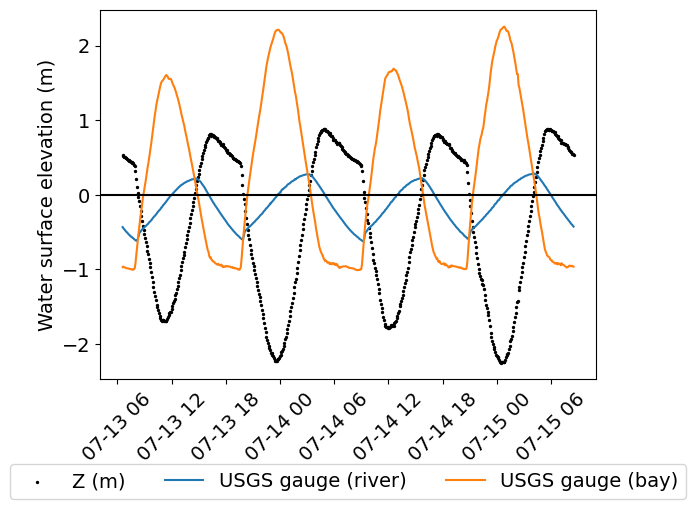

In [6]:
# Import USGS tide gauge data to relate thermistor to tide gauge
plt.close("all")

USGS_tidegauge = CSV.read(joinpath(CACO_dir, "2022/Analysis/Modeling/WL_model_inputs", "HRE_CNRD_USGS_011058798.csv"), DataFrame, header = 28)[2:end, :]

USGS_bayH = parse.(Float64, USGS_tidegauge."218558_00065") .* ft_to_m
USGS_riverH = parse.(Float64, USGS_tidegauge."66254_00065") .* ft_to_m
USGS_datetime = Dates.DateTime.(USGS_tidegauge."datetime", "m/d/y H:M")

# ATS_firstframe_time = IRQIV.ats_ts(I1images)[1]
# find_nearest_time_indices(ATS_time_extrema, USGS_datetime)

# Converting thermistor vertical offset to tide gauge

# Function to find indices of local abs(H) minima -> zero-crossings 
function local_minima_indices(vec::Vector{Float64}; threshold::Float64 = 0.2)
    absvec = abs.(vec)
    inds = [i for i in 2:length(absvec)-1 if absvec[i] < absvec[i-1] && absvec[i] < absvec[i+1] && absvec[i] < threshold]
    return inds
end

# Find overlap between tide gauge and thermistor (proxy for experiment)
therm_overlap_inds = findall(x -> x >= therm_time_extrema[1] && x <= therm_time_extrema[2], USGS_datetime)
USGS_deltaH = [USGS_datetime[therm_overlap_inds], USGS_riverH[therm_overlap_inds] .- USGS_bayH[therm_overlap_inds]]
# Deployed in river side
therm_overlap_inds_river = findall(x -> x >= therm_time_extrema[1] && x < therm_moved_datetime, USGS_datetime)
# Deployed in bay side 
therm_overlap_inds_bay = findall(x -> x > therm_moved_datetime && x <= therm_time_extrema[2], USGS_datetime)
# In subset of original indices, find local minima for river/bay side data
riverH_min_inds = therm_overlap_inds_river[local_minima_indices(USGS_riverH[therm_overlap_inds_river])]
riverH_local_mins = USGS_riverH[riverH_min_inds]
bayH_min_inds = therm_overlap_inds_bay[local_minima_indices(USGS_bayH[therm_overlap_inds_bay])]
bayH_local_mins = USGS_bayH[bayH_min_inds]

# Compare thermistor to tide gauge at multiple points immediately before camera to thermistor was measured
river_offset_times = [USGS_datetime[riverH_min_inds[4]],
    Dates.DateTime("2022-07-14T03:30:00"),
    Dates.DateTime("2022-07-14T06:30:00"),
    Dates.DateTime("2022-07-14T07:30:00"),]

river_offset_inds_USGS = findall(x -> x in river_offset_times, USGS_datetime)
river_offset_inds_therm = findall(x -> x in river_offset_times, therm.DateTime)
river_therm_gauge_offset = Statistics.mean(therm.Pcorrected[river_offset_inds_therm] .- USGS_riverH[river_offset_inds_USGS])

# On bay side, offset is around 0.9 near second peak, but shifts around first time in offset vector:
bay_offset_times = [Dates.DateTime("2022-07-15T04:05:00"),
    Dates.DateTime("2022-07-15T05:00:00"),
    Dates.DateTime("2022-07-15T06:30:00"),
    Dates.DateTime("2022-07-15T07:30:00")]
# Vertical distance from camera to thermistor measured at end on both sides according to notes, offset appears ~constant at these times
bay_offset_inds_USGS = findall(x -> x in bay_offset_times, USGS_datetime)
bay_offset_inds_therm = findall(x -> x in bay_offset_times, therm.DateTime)
bay_therm_gauge_offset = Statistics.mean(therm.Pcorrected[bay_offset_inds_therm] .- USGS_bayH[bay_offset_inds_USGS])

# Subtract gauge to therm offset from camera to thermistor distance
river_gauge_cam_offset = river_therm_cam_offset - river_therm_gauge_offset
bay_gauge_cam_offset = bay_therm_cam_offset - bay_therm_gauge_offset

# Calculate water distance from camera
river_gauge_dist_from_cam = [USGS_datetime[therm_overlap_inds_river], 
    river_gauge_cam_offset .- USGS_riverH[therm_overlap_inds_river]]
bay_gauge_dist_from_cam = [USGS_datetime[therm_overlap_inds_bay], 
    bay_gauge_cam_offset .- USGS_bayH[therm_overlap_inds_bay]]

outflow_time_inds = findall(x -> DateTime("2022-07-14T00:00:00") <= x <= DateTime("2022-07-14T12:00:00"), USGS_deltaH[1])
outflow_tide_inds = findall(x -> x > 0, USGS_deltaH[2][outflow_time_inds])
outflow_tide_inds = outflow_time_inds[outflow_tide_inds] # Get back into original indices 
outflow_tide_times = USGS_deltaH[1][outflow_tide_inds]

plt.figure()
# plt.plot(USGS_datetime[therm_overlap_inds_river], abs.(USGS_riverH[therm_overlap_inds_river]))
# plt.plot(USGS_datetime[therm_overlap_inds_bay], abs.(USGS_bayH[therm_overlap_inds_bay]))
# plt.plot(therm.DateTime, thermP)
# plt.axvline.(USGS_datetime[riverH_min_inds])
# plt.axvline.(USGS_datetime[bayH_min_inds])
# plt.plot(therm.DateTime, therm.Pcorrected)
# plt.scatter(USGS_datetime[therm_overlap_inds_river], USGS_riverH[therm_overlap_inds_river])
# plt.scatter(USGS_datetime[therm_overlap_inds_bay], USGS_bayH[therm_overlap_inds_bay])
# plt.axvline.(river_offset_times)
# plt.axvline.(bay_offset_times)
# plt.plot(therm.DateTime, thermZ)
# plt.plot(river_gauge_dist_from_cam[1], river_gauge_dist_from_cam[2])
# plt.plot(bay_gauge_dist_from_cam[1], bay_gauge_dist_from_cam[2])
# plt.ylabel("Water surface distance from camera (m)")
# plt.legend(["Thermistor", "USGS gauge (river)", "USGS gauge (bay)"])
plt.scatter(USGS_deltaH[1], USGS_deltaH[2], color = "black", s = 2)
plt.plot(USGS_datetime[therm_overlap_inds], (USGS_riverH[therm_overlap_inds]))
plt.plot(USGS_datetime[therm_overlap_inds], (USGS_bayH[therm_overlap_inds]))
plt.legend(["Z (m)", "USGS gauge (river)", "USGS gauge (bay)"], 
    loc = "lower center", bbox_to_anchor=(0.5, -0.35), ncol=3)
plt.ylabel("Water surface elevation (m)")
plt.axhline(0, color = "black")
plt.xticks(rotation=45)
plt.gcf()

In [7]:
# INCORPORATE GEOREFERENCING - river side (same code as bayside)
import Geodesy

# Import dike resurvey data from May 2023
resurvey_dir = joinpath(CACO_dir, "2023/5_23_SiteVisit/Georeferencing/Leica/M_CNRD.TXT")

CNRD_resurvey = CSV.read(resurvey_dir, DataFrames.DataFrame) # Total station recorded in survey ft!!
US_GCP_xyz_resurvey = [CNRD_resurvey[2:7,2] CNRD_resurvey[2:7,3] CNRD_resurvey[2:7,4]] .* ft_to_m
DS_GCP_xyz_resurvey = [CNRD_resurvey[8:12,2] CNRD_resurvey[8:12,3] CNRD_resurvey[8:12,4]] .* ft_to_m

# Convert to geospatial coords using GPS data
antenna_csv = CSV.read(joinpath(CACO_dir, "2023/5_23_SiteVisit/Georeferencing/InertialSense/20230515_173251_base/LOG_SN40107_20230515_173251_0001_DID_GPS1_RTK_POS.csv"), DataFrames.DataFrame)
antenna_lla = Geodesy.LLA(Statistics.mean(antenna_csv."lla[0]"), Statistics.mean(antenna_csv."lla[1]"), Statistics.mean(antenna_csv."lla[2]"))
antenna_utm = Geodesy.UTMZ(antenna_lla, Geodesy.wgs84)

# US_GCP_utm_resurvey = US_GCP_xyz_resurvey + [antenna_utm.x antenna_utm.y antenna_utm.z]
US_GCP_utm_resurvey = US_GCP_xyz_resurvey .+ [antenna_utm.x antenna_utm.y antenna_utm.z] # Add UTM position of antenna to all relative points in m
DS_GCP_utm_resurvey = DS_GCP_xyz_resurvey .+ [antenna_utm.x antenna_utm.y antenna_utm.z] # Add UTM position of antenna to all relative points in m


┌ Warning: thread = 1 warning: parsed expected 6 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV /Users/evanheberlein/.julia/packages/CSV/OnldF/src/file.jl:578


5×3 Matrix{Float64}:
      4.11745e5  4.64267e6  -25.1365
      4.11745e5  4.64267e6  -25.5898
      4.11745e5  4.64267e6  -26.0746
      4.11744e5  4.64268e6  -26.2701
 411744.0        4.64268e6  -27.268

┌ Warning: Too few BHPHeaders to calculate fps!
└ @ IRQIV.FLIRATSFiles /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/src/FLIRATSFiles.jl:415
┌ Warning: Too few BHPHeaders to calculate fps!
└ @ IRQIV.FLIRATSFiles /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/src/FLIRATSFiles.jl:415
┌ Info: (411768.0031563245, 411770.4443634363)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411767.9834967245, 411770.2188593963)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411767.55823976453, 411769.8969740929)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411767.4251945645, 411769.8061492483)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411766.9903059

Finished extrinsic calibration:, 16 iterations, max(|ε|)=5e-10, rms(ε₁-ε₀)=6e-11


┌ Info: Initial guess, χinitial:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sZmlsZQ==.jl:57


ExtrinsicCalibrationParameters
  φ: Float64 0.08726646259971647
  τ: Float64 -2.416726509974452
  σ: Float64 0.23109066719589708
  f: Float64 1214.2857142857144
  x_c: Float64 411770.8466259552
  y_c: Float64 4.6426814979640795e6
  z_c: Float64 -24.207543132360424
dump(χinitial_us) = nothing
ExtrinsicCalibrationParameters
  φ: Float64 -0.20482039987361095
  τ: Float64 -2.663588777346602
  σ: Float64 0.5576101617172943
  f: Float64 921.7624007662248
  x_c: Float64 411769.0569816039
  y_c: Float64 4.642685635728899e6
  z_c: Float64 -24.21088685609575
dump(χcalculated) = nothing
φ diff (degrees) -  16.73534447093977
τ diff (degrees) -  14.144166041454277
σ diff (degrees) -  -18.708188964821062
f diff -  292.52331351948965
x_c diff (meters) -  1.7896443512872793
y_c diff (meters) -  -4.137764819897711
z_c diff (meters) -  0.0033437237353268756


┌ Info: Calibrated values, χcalculated:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sZmlsZQ==.jl:60
┌ Info: Difference between calibrated value and initial guess:
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sZmlsZQ==.jl:64
┌ Info: (411768.0031563245, 411768.06524219736)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411767.9834967245, 411767.9677770917)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411767.55823976453, 411767.515936227)
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/IRQIV.jl/examples/CameraCalibrationHelpers.jl:68
┌ Info: (411767.4251945645, 411767.5068939898)
└ @ Main /Users/evanheberlein/Library/Cl

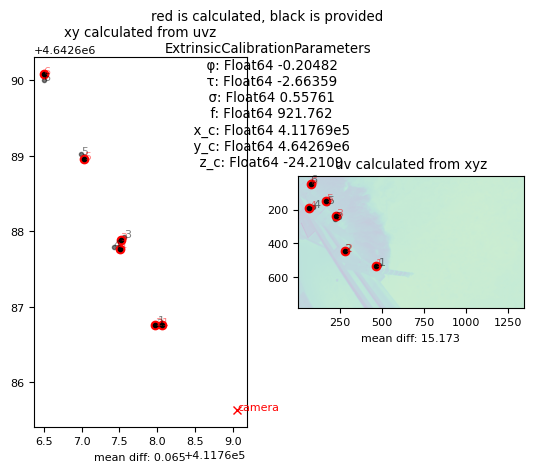

In [8]:
# Camera location calibration setup - RIVER SIDE:
camll_us = [41.931168, -70.064190] # Guess from google maps
camelev_us = sqrt(9^2-2^2)*ft_to_m + (US_GCP_utm_resurvey[1,3]) # add elevation from bridge deck to elevation of first bolt below deck (~4" off?), remove second ft_to_m 12/3/24
cam_LLA_us = Geodesy.LLA(camll_us[1], camll_us[2], camelev_us)
cam_UTM_us = Geodesy.UTMZ(cam_LLA_us, Geodesy.wgs84)

# Camera angle approximation:
azimuth_us = deg2rad(5) # Guess from google maps
# azimuth_us = deg2rad(5-40) # CONVERGE #1
# tilt_us = atan(70/62) # Approx. from photo
# tilt_us = atan(70/62 - deg2rad(55)) # CONVERGE #1
tilt_us = -pi/2 - atan(70/62) # updated 12/3/24 - negative from vertical
roll_us = atan(20/85) # Approx. from photo
# roll_us = atan(20/85 + deg2rad(45)) # CONVERGE #1

# Initial guess of camera's extrinsic parameters:
χinitial_us = IRQIV.ExtrinsicCalibrationParameters(azimuth_us, tilt_us, roll_us, fl, cam_UTM_us.x, cam_UTM_us.y, cam_UTM_us.z) # can also play with height
# χinitial = IRQIV.ExtrinsicCalibrationParameters(azimuth_us, tilt_us, roll_us, fl, cam_UTM_us.x-1, cam_UTM_us.y+2, cam_UTM_us.z) # CONVERGE #1

# UTM coordinates of GCPs:
# TrueGCPxyz = [GCPxyz_us[:,1] GCPxyz_us[:,2] GCPzg_us]

# Pixel coordinates of GCPs, before accounting for radial distortion:
DistortedImageGCPuv_us  = [481 535 # 1L
                        270 446 # 1H
                        215 253 # 2L
                        94 188 # 2H
                        174 159 # 3
                        83 43] # 4
                        #474 65] # board o1

## Remove radial distortion from GCP target coordinates:
TrueGCPuv_us = hcat(IRQIV.RemoveRadialDistortion(DistortedImageGCPuv_us[:,1], DistortedImageGCPuv_us[:,2], Camera)...)

# Optionally, load an IR image and plot it in the background:
FLIR_filename_us = raw"/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003310.ats"
IRimages_us = LoadATSImageSequence(FLIR_filename_us, 1, 2022)
plt.close("all")
plt.rc("font", size=8)
GraphicallyExploreInitialCalibrationGuess(TrueGCPuv_us, US_GCP_utm_resurvey, χinitial_us, ι, IRimages_us[1])
plt.gcf()

# Camera location calibration

###############################################################################

TrueGCPxyz_us = US_GCP_utm_resurvey # US_GCP_utm_combined

χcalculated = ExtrinsicCalibration(
    TrueGCPuv_us,
    TrueGCPxyz_us,
    χinitial_us,
    ι,
    MaxIterations = 50,
    PrintoutStats=true)
# ###############################################################################
@info "Initial guess, χinitial:"
@show dump(χinitial_us)
# 
@info "Calibrated values, χcalculated:"
@show dump(χcalculated)
# 
# Describe how much the calibration changed each parameter:
@info "Difference between calibrated value and initial guess:"
for (i,x) in enumerate(fieldnames(typeof(χcalculated)))
    if i <= 3
        println("$x diff (degrees) -  $(rad2deg(getfield(χinitial_us, x) - getfield(χcalculated, x)))")
    elseif i == 4
        println("$x diff -  $(getfield(χinitial_us, x) - getfield(χcalculated, x))")
    else
        println("$x diff (meters) -  $(getfield(χinitial_us, x) - getfield(χcalculated, x))")
    end
end

dlt_calculated = IRQIV.DLT(χcalculated, FLIR_SC8303_17mm)

plt.close("all")
plt.rc("font", size=8)
GraphicallyExploreInitialCalibrationGuess(TrueGCPuv_us, TrueGCPxyz_us, χcalculated, ι, IRimages_us[1])
plt.gcf()

In [9]:
# Fit streamlines to vector field functions

import DifferentialEquations
import StaticArrays

function meshgrid(x::AbstractVector, y::AbstractVector)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

function vector_field(u, p, t)
    x, y = u
    U = u_interp(x, y)
    V = v_interp(x, y)
    return StaticArrays.SA[U, V]
end

# Termination condition function
function terminate_at_bounds(u, t, integrator)
    x, y = u[2], u[1]
    
    # Check if out of image bounds
    if x < 1 || x > Img_dims[2] || y < 1 || y > Img_dims[1]
        return true
    end
    
    # Check if x is greater than the interpolated x-coordinate of us_shadow
    interpolated_x = shadow_interp(y)
    if x < interpolated_x
        return true
    end
    
    return false
end

# Termination action function
function terminate_action!(integrator)
    DifferentialEquations.terminate!(integrator)
end

# Compute streamline function
function compute_streamline(start_point)
    # Convert the start point to a StaticArray
    start_point_sa = StaticArrays.SA[start_point[1], start_point[2]]

    # Set time span for the ODE solver
    tspan = (0.0, 200.0)  # Adjust the time span as needed

    # Create the DiscreteCallback
    cb = DifferentialEquations.DiscreteCallback(terminate_at_bounds, terminate_action!)

    # Define the ODEProblem with the initial condition and vector field
    prob = DifferentialEquations.ODEProblem(vector_field, start_point_sa, tspan)

    # Solve the ODEProblem with the callback
    sol = DifferentialEquations.solve(prob, DifferentialEquations.Tsit5(), callback=cb)

    # Extract and return the streamline coordinates
    streamline_coords = hcat(sol.u...)'
    # return streamline_coords
    coords = [(sol[1, i], sol[2, i]) for i in 1:length(sol.t)]
    return coords
    # print(streamline_coords)
end

# Function definitions - line identification

# Bresenham's line algorithm to get pixels for a line
function bresenham_line(x0, y0, x1, y1)
    pixels = []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = x0 < x1 ? 1 : -1
    sy = y0 < y1 ? 1 : -1
    err = dx - dy

    while true
        push!(pixels, (x0, y0))
        if x0 == x1 && y0 == y1
            break
        end
        e2 = 2 * err
        if e2 > -dy
            err -= dy
            x0 += sx
        end
        if e2 < dx
            err += dx
            y0 += sy
        end
    end
    return pixels
end

# Function to determine if a point is beyond the diagonal line
function right_of_diagonal(x, y, x_start, y_start, x_end, y_end)
    # Calculate the cross product to determine the side of the line
    line_value = (x_end - x_start) * (y - y_start) - (y_end - y_start) * (x - x_start)
    return line_value < 0  # Adjust depending on which side you want
end

# Function to calculate the slope of each labeled component if it exceeds the length threshold
function calculate_slope_for_components(labels::AbstractArray{Int}, num_components::Int, length_threshold::Int)
    slopes = Dict{Int, Float64}()
    x_lengths = Dict{Int, Float64}()
    
    for label in 1:num_components
        # Find the coordinates of all pixels in the component
        component_coords = findall(x -> x == label, labels)
        
        # Only consider the component if it exceeds the length threshold
        if length(component_coords) > length_threshold
            # Find the first and last pixel coordinates in the component
            first_pixel = component_coords[1]
            last_pixel = component_coords[end]
            
            # Calculate the slope between the first and last pixel
            x1, y1 = first_pixel[2], first_pixel[1]  # (x1, y1)
            x2, y2 = last_pixel[2], last_pixel[1]    # (x2, y2)
            
            if x2 != x1
                slope = (y2 - y1) / (x2 - x1)
            else
                slope = Inf  # Vertical line (undefined slope)
            end
            
            # Store the slope in a dictionary
            slopes[label] = slope
            x_lengths[label] = x2 - x1
        end
    end
    
    return slopes, x_lengths
end

function float_to_bool(edges::Matrix{Float64}, threshold::Float64)
    return edges .> threshold
end

# Label components function for diagonal relationships (instead of 4 connected)
function label_components_8_connected(edges::AbstractArray{Bool})
    rows, cols = size(edges)
    labels = zeros(Int, rows, cols)
    current_label = 0
    
    function in_bounds(r, c)
        return 1 <= r <= rows && 1 <= c <= cols
    end
    
    function dfs(r, c, label)
        stack = [(r, c)]
        while !isempty(stack)
            cr, cc = pop!(stack)
            if in_bounds(cr, cc) && edges[cr, cc] && labels[cr, cc] == 0
                labels[cr, cc] = label
                # Add all 8 neighbors
                for dr in -1:1, dc in -1:1
                    if !(dr == 0 && dc == 0)  # skip the current pixel itself
                        push!(stack, (cr + dr, cc + dc))
                    end
                end
            end
        end
    end
    
    for r in 1:rows
        for c in 1:cols
            if edges[r, c] && labels[r, c] == 0
                current_label += 1
                dfs(r, c, current_label)
            end
        end
    end
    
    return labels, current_label
end

function calculate_path_length(coords::Vector{Tuple{Float64, Float64}})
    # Ensure there are at least two points to calculate a path
    if length(coords) < 2
        return 0.0
    end
    
    # Initialize path length
    path_length = 0.0
    
    # Loop through consecutive points
    for i in 2:length(coords)
        x1, y1 = coords[i-1]
        x2, y2 = coords[i]
        # Add Euclidean distance between consecutive points
        path_length += sqrt((x2 - x1)^2 + (y2 - y1)^2)
    end
    
    return path_length
end


function remove_duplicate_coords(coords::Vector{Any})
    unique_coords = [coords[1]]  # Start with the first coordinate
    for i in 2:length(coords)
        if coords[i] != coords[i-1]  # Check if the current coordinate differs from the previous one
            push!(unique_coords, coords[i])
        end
    end
    return unique_coords
end

#Funcitons for interpolating streamline to physical coordinates to assemble STIV image

# Step 1: Calculate pairwise distances between pixels
function calculate_pairwise_distances(coords::Vector{Tuple{Float64, Float64}})
    distances = Float64[]
    for i in 2:length(coords)
        x1, y1 = coords[i-1]
        x2, y2 = coords[i]
        d = sqrt((x2 - x1)^2 + (y2 - y1)^2)  # Euclidean distance
        push!(distances, d)
    end
    return distances
end

# Step 2: Interpolate intensities while preserving original points
# Changed to interpolate using minimum distance rather than maximum distance
function interpolate_preserving_points(coords::Vector{Tuple{Float64, Float64}}, intensities::Vector{Float64})
    # Calculate pairwise distances
    pairwise_distances = calculate_pairwise_distances(coords)
    
    # Use the maximum distance between consecutive points as the resolution
    min_distance = minimum(pairwise_distances)

    # Generate uniform distances based on this resolution
    cumulative_distances = [0.0; cumsum(pairwise_distances)]
    total_length = cumulative_distances[end]
    uniform_distances = 0:min_distance:total_length

    # Interpolate intensities at the uniform distances
    interpolation = LinearInterpolation(cumulative_distances, intensities, extrapolation_bc=Line())
    interpolated_intensities = [interpolation(d) for d in uniform_distances]

    return uniform_distances, interpolated_intensities
end



interpolate_preserving_points (generic function with 1 method)

In [10]:
# Big loop setup - file times
river_files = 3347:3387 # in notes tide turns during 3348, but z is positive at time during 3347

FLIR_extrema_vec = []

for (file_ind, file) in enumerate(river_files)

    FLIR_filename = joinpath("/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-00" * string.(file) * ".ats")

    FLIR_meta_summary = IRQIV.FLIRATSFiles.FindATSFileMetadata(FLIR_filename, ATSfps = NaN, ats_year = ats_year)
    lastframe = FLIR_meta_summary.EstimatedTotalFrames
    _,FLIR_meta_full = IRQIV.FLIRATSFiles.LoadMultipleFrames(FLIR_meta_summary, collect(1:1:lastframe), ats_year=ats_year, ReadFrame=false)
    FLIR_meta_time = TimeZones.ZonedDateTime(
        IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = ats_year)[1], # First frame corresponds to file modeified time
        TimeZones.tz"America/New_York"
    )

    file_meta_time = TimeZones.ZonedDateTime(Dates.unix2datetime(stat(FLIR_filename).mtime), TimeZones.tz"UTC")
    file_meta_time = TimeZones.astimezone(file_meta_time, TimeZones.tz"America/New_York")

    meta_time_offset = FLIR_meta_time - file_meta_time

    FLIR_time_corrected = IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = ats_year) .- meta_time_offset
    FLIR_time_extrema = extrema(FLIR_time_corrected)

    push!(FLIR_extrema_vec, FLIR_time_extrema)
end

FLIR_file_inds = []

for (i, t) in enumerate(outflow_tide_times)
    # Flatten extrema into list of (time, file_index)
    bounds = [(start, j) for (j, (start, _)) in enumerate(FLIR_extrema_vec)]
    append!(bounds, [(stop, j) for (j, (_, stop)) in enumerate(FLIR_extrema_vec)])

    # Find closest bound
    dists = abs.(t .- first.(bounds))
    closest_ind = argmin(dists)
    push!(FLIR_file_inds, last(bounds[closest_ind]))

    if t > maximum(last.(FLIR_extrema_vec))
        break
    end
end

river_files[FLIR_file_inds]


53-element Vector{Int64}:
 3347
 3347
 3348
 3349
 3351
 3352
 3352
 3353
 3354
 3354
    ⋮
 3381
 3381
 3382
 3383
 3384
 3384
 3385
 3387
 3386

In [11]:
# MQD setup

# Subwindow dimensions remain constant
const M=32 # subwindow dims - horiz, N = vert.
const N=32
# Search radius - variance STIV lines steeper slopes approx 35pix/frame
const rhoI = 38 # how far away to search (+/-) - i=short side, j= long side
const rhoJ = 38 # Set these to visual estimates - plot one pair
MQD_parameters = (M=M, N=N, rhoI=rhoI, rhoJ=rhoJ)

# Set ATS parameters
Img_dims = [784, 1344] # Image dims: 784 x 1344
DtFrames = 1                    # Δt, frames (ATS 3116 is at 10Hz)
data_output_rate_frames = 1    # difference between I1 sequence, frames - time sep of output
nImagePairs = 101 # can set to inf - all frames in file

# Crop AOI to area just outside sluicegate
right_crop = 900
# Offset distance (horizontal left shift)
offset_distance = 150  # Pixels

subwincorners = CartesianIndices(( (N+rhoI):N:(Img_dims[1]-(N+rhoI+1)),
                                    (M+rhoJ):M:right_crop))

# Function to select nImagePairs frames from anywhere in .ATS file:
function get_window_indices(center_ind::Int, nImagePairs::Int, max_index::Int)
    half_span = (nImagePairs - 1) ÷ 2

    # Start with the centered window
    start_ind = center_ind - half_span
    end_ind = center_ind + half_span

    # Adjust if start goes below 1
    if start_ind < 1
        start_ind = 1
        end_ind = start_ind + nImagePairs - 1
    end

    # Adjust if end goes beyond max_index - 1
    if end_ind > max_index - 1
        end_ind = max_index - 1
        start_ind = end_ind - nImagePairs + 1
        start_ind = max(start_ind, 1)  # in case max_index is too small
    end

    return range(start_ind, step = data_output_rate_frames, end_ind)
end

# Shadow interpolation setup for integration start line
shadow_start_uv = [182,1] # [u,v]
shadow_end_uv = [764,784] # [u,v]
u_start, v_start = shadow_start_uv
u_end, v_end = shadow_end_uv
# Interpolate boundary condition where streamlines end - don't change variable name, feeds into terminate_at_bounds()
shadow_interp = LinearInterpolation(Float64[v_start, v_end], Float64[u_start, u_end]; extrapolation_bc=Line())
# Get pixels along shadow line
shadow_pixels_uv = bresenham_line(v_start, u_start, shadow_end_uv[2], shadow_end_uv[1])

# Functions for STIV: automatic STIV detection routine from Fujita et al. 2019 https://doi.org/10.1007/s10652-018-9651-3
import HDF5
import FFTW
plt.pygui(true) # sets plots to popup instead of inline

# Polygon mask functions from https://github.com/JuliaImages/ImageDraw.jl/issues/56

# This function returns whether or not a point falls within a polygon
function point_in_polygon(poly_xs::Vector{T}, poly_ys::Vector{T}, x::T, y::T) where T<: Real
    n_verts = length(poly_xs)
    j = n_verts
    c = false
    for i in 1:n_verts
        if (((poly_ys[i] <= y) && (y < poly_ys[j])) || ((poly_ys[j] <= y) && (y < poly_ys[i]))) && 
            (x < (poly_xs[j] - poly_xs[i]) * (y - poly_ys[i]) / (poly_ys[j] - poly_ys[i]) + poly_xs[i])
            c = !c
        end
        j = i
    end
    return c
end

# This function uses the above function to populate a boolean mask within the given polygon
function draw_polygon!(mask::Matrix{Bool}, poly_xs::Vector{Int}, poly_ys::Vector{Int})
    min_x, max_x = max(minimum(poly_xs), 1), min(maximum(poly_xs), size(mask, 2))
    min_y, max_y = max(minimum(poly_ys), 1), min(maximum(poly_ys), size(mask, 1))
    for y in min_y:max_y
        for x in min_x:max_x
            if point_in_polygon(poly_xs, poly_ys, x, y)
                mask[y, x] = true
            end
        end
    end
end

# This function uses the above two function to create the circular mask for the STIV polar coordinate transform
function polygons_to_mask(polygons::Array{Matrix{T}, 1} where T <: Real, max_x::Int, max_y::Int)::Matrix{Bool}
    poly_mask = zeros(Bool, max_y, max_x)  # Initialize a Bool matrix with all values set to false
    for p in polygons
        draw_polygon!(poly_mask, round.(Int, p[:, 1]), round.(Int, p[:, 2]))
    end
    return poly_mask
end

# STIV setup

center = Int(ceil(nImagePairs/2))
radius = center-1
# Define angles and compute coordinates for the circle mask
θ_c = range(1, stop = 360, length = 360)
xc = radius * cosd.(θ_c) .+ center
yc = radius * sind.(θ_c) .+ center
# Create a circular mask
circ_mask = polygons_to_mask([hcat(xc, yc)], center+radius, center+radius)
circ_nan = ones(Float64, size(circ_mask))
circ_nan[.!circ_mask] .= NaN
# Initialize arrays for polar transform
θ = zeros(Float64, nImagePairs, nImagePairs)
ρ = zeros(Float64, nImagePairs, nImagePairs)
Tx = zeros(Float64, nImagePairs, nImagePairs)
Ty = zeros(Float64, nImagePairs, nImagePairs)
M_STIV = 15  # "coefficient of intensification" from Fujita
# Calculate theta and ρ for each pixel within the mask - polar transform
for i in 1:nImagePairs
    for j in 1:nImagePairs
        if circ_mask[i, j]
            Tx[i,j] = center - j
            Ty[i,j] = center - i
            θ[i,j] = atand(Ty[i,j] / Tx[i, j]) # -90 to 90
            ρ[i,j] = M_STIV * log(sqrt(Tx[i,j]^2 + Ty[i,j]^2)) 
        end
    end
end
# Initialize polar coordinates
AngleIncrement = 1
AngleVec = [0:1*AngleIncrement:179]


1-element Vector{StepRange{Int64, Int64}}:
 0:1:179

In [12]:
# BIG LOOP

time_ind = 1

outflow_tide_times = outflow_tide_times[1:length(FLIR_file_inds)] # Clip times to length 

n_gauge = length(outflow_tide_times)
river_outputs = DataFrame(
    times = outflow_tide_times,
    time_diff = Vector{Union{Millisecond, Missing}}(missing, n_gauge),
    frame_ind = Vector{Union{Int, Missing}}(missing, n_gauge),
    WSE_gage = Vector{Union{Float64, Missing}}(missing, n_gauge),
    Z = Vector{Union{Float64, Missing}}(missing, n_gauge),
    slopes = Vector{Union{Vector{Float64}, Missing}}(missing, n_gauge), 
    velocities = Vector{Union{Vector{Float64}, Missing}}(missing, n_gauge)
)

skip_gauge = 4

for (time_ind, gage_time) in enumerate(outflow_tide_times[skip_gauge+1:end])
    time_ind += skip_gauge

    ### 1.) Import file associated w/ gage measurement
    FLIR_ind = FLIR_file_inds[time_ind]
    FLIR_file_num = river_files[FLIR_ind]
    FLIR_filename = joinpath("/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-00" * string.(FLIR_file_num) * ".ats")

    # Extract FLIR metadata
    FLIR_meta_summary = IRQIV.FLIRATSFiles.FindATSFileMetadata(FLIR_filename, ATSfps = NaN, ats_year = ats_year)
    lastframe = FLIR_meta_summary.EstimatedTotalFrames
    _,FLIR_meta_full = IRQIV.FLIRATSFiles.LoadMultipleFrames(FLIR_meta_summary, collect(1:1:lastframe), ats_year=ats_year, ReadFrame=false)
    FLIR_meta_time = TimeZones.ZonedDateTime(
        IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = ats_year)[1], # First frame corresponds to file modeified time
        TimeZones.tz"America/New_York"
    )

    # Extract metadata from file using base functions
    file_meta_time = TimeZones.ZonedDateTime(Dates.unix2datetime(stat(FLIR_filename).mtime), TimeZones.tz"UTC")
    file_meta_time = TimeZones.astimezone(file_meta_time, TimeZones.tz"America/New_York")

    # Calculate and correct for offset between two metadata times
    meta_time_offset = FLIR_meta_time - file_meta_time
    FLIR_time_corrected = IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(FLIR_meta_full, ats_year = ats_year) .- meta_time_offset
    
    # Find index corresponding to closest time between image and tide gage measurement
    time_diffs = abs.(gage_time .- FLIR_time_corrected)
    FLIR_time_ind = argmin(time_diffs)
    river_outputs.time_diff[time_ind] = minimum(time_diffs)
    river_outputs.frame_ind[time_ind] = FLIR_time_ind

    # Get water surface elevation
    USGS_ind = outflow_tide_inds[time_ind]
    WSE_gage = χcalculated.z_c - river_gauge_dist_from_cam[2][USGS_ind] # in camera coordinate system
    river_outputs.WSE_gage[time_ind] = WSE_gage
    river_outputs.Z[time_ind] = USGS_deltaH[2][USGS_ind]

    ### 2.) Select images for MQD
    I1inds = get_window_indices(FLIR_time_ind, nImagePairs, length(FLIR_time_corrected)) 
    I2inds = I1inds .+ DtFrames
    @assert isfile(FLIR_filename)
    I1images = LoadATSImageSequence(FLIR_filename, I1inds, ats_year)
    I2images = LoadATSImageSequence(FLIR_filename, I2inds, ats_year)
    ATSframerate = I1images.Metadata.Estimatedfps

    # Remove image pairs when at least one image took place during NUC (calibration) mode:
    if any(isnuc(I1images.Headers)) || any(isnuc(I2images.Headers))
        nuc_frames = isnuc(I1images.Headers) .| isnuc(I2images.Headers)
        I1inds = I1inds[.!( isnuc(I1images.Headers) .| isnuc(I2images.Headers) )]
        I2inds = I2inds[.!( isnuc(I1images.Headers) .| isnuc(I2images.Headers) )]
        I1images = LoadATSImageSequence(FLIR_filename, I1inds, ats_year)
        I2images = LoadATSImageSequence(FLIR_filename, I2inds, ats_year)
    end

    # Initialize MQD calculation:
    MQD_variables = initialize_MQD(I1images,
                                I2images,
                                subwincorners,
                                N, M,
                                rhoI, rhoJ)                              

    # Perform the MQD analysis:
    subpix_shifts_i, subpix_shifts_j, performance_message = perform_MQD(
        I1images, I2images, subwincorners, MQD_variables)

    mean_shifts_i = dropdims(NaNStatistics.nanmean(subpix_shifts_i, dims = 3), dims = 3)
    mean_shifts_j = dropdims(NaNStatistics.nanmean(subpix_shifts_j, dims = 3), dims = 3)
    x_vector = [index[2] for index in subwincorners]
    y_vector = [index[1] for index in subwincorners]


    
    ### 3.) Interpolate vector field from MQD results
    i = Float64[y_vector[:,1]...]
    j = Float64[x_vector[1,:]...]
    X, Y = meshgrid(j, i)
    # Create linear interpolants for the vector field - make i & j shifts negative to integrate upstream
    global u_interp = extrapolate(interpolate((i, j), -mean_shifts_i, Gridded(Linear())), Line())
    global v_interp = extrapolate(interpolate((i, j), -mean_shifts_j, Gridded(Linear())), Line())

    shadow_start_xy = IRQIV.uvz2xy(u_start, v_start, WSE_gage, dlt_calculated)
    shadow_end_xy = IRQIV.uvz2xy(shadow_end_uv[1], shadow_end_uv[2], WSE_gage, dlt_calculated)
    # Calculate the total distance of the line (Euclidean distance)
    delta_x = shadow_end_xy[1] - shadow_start_xy[1]
    delta_y = shadow_end_xy[2] - shadow_start_xy[2]
    line_length = sqrt(delta_x^2 + delta_y^2)
    # Get physical locations of all pixels along line
    shadow_pixels_xy = fill((0.0, 0.0), length(shadow_pixels_uv))
    for (coord_ind, coord) in enumerate(shadow_pixels_uv)
        v_ind, u_ind = coord
        x_coord, y_coord = IRQIV.uvz2xy(u_ind, v_ind, WSE_gage, dlt_calculated)
        shadow_pixels_xy[coord_ind] = (x_coord, y_coord)
    end
    
    # Number of equidistant points you want
    n = 40
    max_n = 200
    
    # Create empty vector of sets, one for each streamline
    StreamlinePixelsSingle = []
    
    while n < max_n
        plt.close("all")
    
        scratch_streamlines = []
    
        # Generate 40 equidistant distances along the line (in terms of total length)
        distances = LinRange(0, line_length, n)
    
        # Now calculate the corresponding (x, y) positions for each distance
        # Parametrize the line using the formula: (x, y) = (x_start + t * delta_x, y_start + t * delta_y)
        equidistant_points = [shadow_start_xy + (distance / line_length) * StaticArrays.SVector(delta_x, delta_y) for distance in distances]
    
        # Now, for each equidistant point, find the closest pixel in shadow_pixels_xy
        start_point_indices = []
        for eq_point in equidistant_points
            # Find the pixel in shadow_pixels_xy that has the minimum distance to eq_point
            distances_to_pixels = [LinearAlgebra.norm(eq_point .- pixel) for pixel in shadow_pixels_xy]
            min_index = argmin(distances_to_pixels)  # Find the index of the minimum distance
            push!(start_point_indices, min_index)
        end
    
        initial_conditions = shadow_pixels_uv[start_point_indices]
        all_streamline_coords = [] # Initialize default array
        # Compute streamlines for all starting points
        for sp in initial_conditions
            coords = compute_streamline(sp)
            push!(all_streamline_coords, coords)
        end
    
        # Iterate through each streamline in `all_streamline_coords`
        for coords in all_streamline_coords
            # Define a set to store unique pixels for the current streamline
            streamline_pixels = []  # Use an ordered vector instead of a set
    
            for k in 1:length(coords)-1
                y0, x0 = coords[k]
                y1, x1 = coords[k+1]
    
                # Calculate Bresenham pixels for the current segment
                bresenham_pixels = bresenham_line(round(Int, y0), round(Int, x0), round(Int, y1), round(Int, x1))
                
                # Filter pixels that are beyond the diagonal line
                filtered_pixels = filter(p -> right_of_diagonal(p[2], p[1], u_start, v_start, u_end, v_end), bresenham_pixels)
    
                # Add pixels to the current streamline set
                append!(streamline_pixels, filtered_pixels)    
            end
            
            # Add the unique set of pixels for this streamline to the overall list
            push!(scratch_streamlines, streamline_pixels)
        end
    
        # collect() puts vector of indices in order
        scratch_streamlines = [collect(streamline) for streamline in scratch_streamlines]
    
        # reverse() first nImagePairs to account for reverse integration of vector field
        scratch_streamlines = [
            reverse(length(streamline) > nImagePairs ? streamline[1:nImagePairs] : streamline)
            for streamline in scratch_streamlines
        ]
        
        # Filter scratch_streamlines for valid image indices and length = nImagePairs
        scratch_streamlines = [
            streamline for streamline in scratch_streamlines
            if length(streamline) >= nImagePairs && 
            all(p -> p[1] > 0 && p[2] > 0, streamline) &&
            all(p -> p[1] <= Img_dims[1] && p[2] <= Img_dims[2], streamline)
        ]
    
        # Check if we have 40 valid streamlines
        if length(scratch_streamlines) == 40
            StreamlinePixelsSingle = scratch_streamlines
            break
        end
    
        n += 1  # Increase n and try again
    end
    if isempty(StreamlinePixelsSingle)
        @warn "Skipping timestep: Failed to generate 40 streamlines before reaching max_n = $max_n"
        continue  # This skips the current timestep in the outer loop
    end    



    ### 4.) implement STIV from Fujita 2019
    
    slope_vec = []
    inds_vec = zeros(Int, length(AngleVec[1]))
    μ = zeros(Float64, length(AngleVec[1]))
    STIV_vels = zeros(length(StreamlinePixelsSingle))
    pixel_sizes = zeros(length(StreamlinePixelsSingle))

    for (stream_ind, streamline_uv) in enumerate(StreamlinePixelsSingle)
        skip_streamline = false  # <-- reset for each new streamline
        
        # Locate the intersection index for trimming
        streamline_uv = remove_duplicate_coords(streamline_uv)
    
        # Calculate physical locations of STIV lines
        xy_coords = fill((0.0, 0.0), length(streamline_uv))
        for (coord_ind, coord) in enumerate(streamline_uv)
            v_ind, u_ind = coord
            x_coord, y_coord = IRQIV.uvz2xy(u_ind, v_ind, WSE_gage, dlt_calculated)
            xy_coords[coord_ind] = (x_coord, y_coord)
        end
    
        # Create empty vector of vectors (each vector is 1 STIV column)
        STIV_vec = Vector{Vector{Float64}}()
        dist_vec = nothing
    
        # Extract pixel values for the trimmed streamline across the image time series
        for img = 1:size(I1images, 3)
            pixel_intensities = zeros(length(streamline_uv))
            for coord = 1:length(streamline_uv)
                i, j = streamline_uv[coord]
                pixel_intensities[coord] = I1images[i, j, img] # (i, j) for row, col order
            end
            uniform_distances, interpolated_intensities = interpolate_preserving_points(xy_coords, pixel_intensities)
            push!(STIV_vec, interpolated_intensities)
    
            if img == 1
                dist_vec = collect(uniform_distances)
                pixel_sizes[stream_ind] = dist_vec[2]

                # Skip this streamline if there aren't enough distance samples
                if length(interpolated_intensities) < nImagePairs
                    @warn "Skipping streamline $stream_ind: only $(length(interpolated_intensities)) pixels < $nImagePairs"
                    skip_streamline = true
                    break  # Exit the image loop early
                end
            end
        end
    
        if skip_streamline
            continue  # Skip to next streamline in outer loop
        end
    
        # Unpack the vector of vectors to a 2D array
        STIV_vec = hcat(STIV_vec...)
    
        # Assemble STIV space-time diagram
        for row = 1:size(STIV_vec, 1)
            STIV_vec[row, :] = STIV_vec[row, :] .- Statistics.mean(STIV_vec[row, :])
        end
    
        # Fujita STIV
        y = STIV_vec[end-(nImagePairs-1):end, :]
        # Compute the 2D Fourier transform and the power spectrum of the STIV window (Rxy)
        Rxy = FFTW.ifft(abs.(FFTW.fft(y)).^2)
        Rxy = FFTW.fftshift(abs.(Rxy)) # Shifts zero-frequency component to center of spectrum
        # Apply the circular mask to Rxy
        Rxy_pol_norm = Rxy .* circ_nan ./ Rxy[center, center]
        ρ_Rxy = ρ .* circ_nan
        θ_Rxy = θ .* circ_nan
        # Log-transformation for distance from STIV window center
        ρ_max = M*log(minimum([maximum(filter(!isnan,Tx)),maximum(filter(!isnan,Ty))]))
        # Loop through vector of angles
        for i in 1:length(AngleVec[1])
            a = i-90 # Convert index back to angle of theta
            inds = findall(θ -> round(θ) == a, θ[:]) # Find all pixels within each degree increment
            inds_vec[i] = length(inds)
            Rxy_int = sum(Rxy_pol_norm[inds])/inds_vec[i] # Square summed intensity within each degree to amplify signal (optional), normalize by number of pixels in degree
            μ[i] = (1/ρ_max)*Rxy_int # Calculate normalized integral value for each degree
        end
    
        # Exclude invalid measurements 
        exclude_inds = Set([0, 90, 180])  # Indices to exclude
        valid_inds = [i for i in eachindex(μ) if !isnan(μ[i]) && !(i in exclude_inds)]
        max_local_idx = argmax(@view μ[valid_inds])
        φ = valid_inds[max_local_idx] - 90 # Convert integral back to angles centered at 0
        push!(slope_vec, φ) # Populate vector of measurements with result
        Sx = pixel_sizes[stream_ind]
        St = 1/ATSframerate
        STIV_vels[stream_ind] = Sx/St*tand(φ)

    end

    river_outputs.slopes[time_ind] = slope_vec
    river_outputs.velocities[time_ind] = STIV_vels

end

river_outputs


1.0%┣▍                                         ┫ 1/101 [00:04<Inf:Inf, InfGs/it]
8.9%┣████▏                                          ┫ 9/101 [00:05<01:02, 1it/s]
16.8%┣███████▋                                     ┫ 17/101 [00:06<00:33, 3it/s]
23.8%┣██████████▊                                  ┫ 24/101 [00:06<00:21, 4it/s]
24.8%┣███████████▏                                 ┫ 25/101 [00:07<00:21, 4it/s]
30.7%┣█████████████▉                               ┫ 31/101 [00:07<00:16, 5it/s]
32.7%┣██████████████▊                              ┫ 33/101 [00:08<00:16, 4it/s]
39.6%┣█████████████████▉                           ┫ 40/101 [00:08<00:12, 5it/s]
40.6%┣██████████████████▎                          ┫ 41/101 [00:08<00:12, 5it/s]
46.5%┣█████████████████████                        ┫ 47/101 [00:08<00:09, 6it/s]
48.5%┣█████████████████████▉                       ┫ 49/101 [00:08<00:09, 6it/s]
54.5%┣████████████████████████▌                    ┫ 55/101 [00:08<00:07, 6it/s]
56.4%┣██████████████████████

Performance stats (MQD loop only)
time [s]                    11.170905333
subwins/s             4936.5739262952175
allocations [GB]                   18.58
allocations [MB/subwin]               34.03
time [m]                            0.19
total n subwindows                 55146
n image pairs                        101
n subwindows in FOV                  546
size(subwindows)                (21, 26)
M, N                            (32, 32)
rhoI, rhoJ                      (38, 38)
allocations [B]              18579371752
allocations [MB]                18579.37
gc time [s]                   1.70522025
gc stats            Base.GC_Diff(18579371752, 221015, 1, 7962980, 60647, 219860, 1705220250, 8, 0)
number of threads                      8
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     241313 s          0 s     113319 s     693295 s          0 s
#2  2400 MHz     231432 s          0 s     104168 s

1.0%┣▍                                         ┫ 1/101 [00:00<Inf:Inf, InfGs/it]
8.9%┣████                                          ┫ 9/101 [00:00<00:05, 20it/s]
9.9%┣████▌                                        ┫ 10/101 [00:00<00:05, 18it/s]
14.9%┣██████▌                                     ┫ 15/101 [00:01<00:04, 25it/s]
16.8%┣███████▍                                    ┫ 17/101 [00:01<00:05, 15it/s]
18.8%┣████████▎                                   ┫ 19/101 [00:01<00:05, 16it/s]
20.8%┣█████████▏                                  ┫ 21/101 [00:01<00:05, 17it/s]
22.8%┣██████████                                  ┫ 23/101 [00:01<00:04, 18it/s]
24.8%┣███████████▏                                 ┫ 25/101 [00:03<00:08, 9it/s]
28.7%┣█████████████                                ┫ 29/101 [00:03<00:08, 9it/s]
32.7%┣██████████████▊                              ┫ 33/101 [00:04<00:09, 7it/s]
36.6%┣████████████████▌                            ┫ 37/101 [00:04<00:08, 8it/s]
40.6%┣██████████████████▎   

Performance stats (MQD loop only)
time [s]                    10.715575125
subwins/s              5146.340663632835
allocations [GB]                   18.16
allocations [MB/subwin]               33.26
time [m]                            0.18
total n subwindows                 55146
n image pairs                        101
n subwindows in FOV                  546
size(subwindows)                (21, 26)
M, N                            (32, 32)
rhoI, rhoJ                      (38, 38)
allocations [B]              18157843808
allocations [MB]                18157.84
gc time [s]                  2.420940499
gc stats            Base.GC_Diff(18157843808, 220988, 2, 1827324, 55154, 219180, 2420940499, 5, 0)
number of threads                      8
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     241346 s          0 s     113368 s     693390 s          0 s
#2  2400 MHz     231465 s          0 s     104214 s

1.0%┣▍                                         ┫ 1/101 [00:00<Inf:Inf, InfGs/it]
8.9%┣████                                          ┫ 9/101 [00:01<00:08, 12it/s]
16.8%┣███████▍                                    ┫ 17/101 [00:01<00:07, 12it/s]
22.8%┣██████████                                  ┫ 23/101 [00:01<00:05, 16it/s]
24.8%┣███████████                                 ┫ 25/101 [00:03<00:08, 10it/s]
32.7%┣██████████████▍                             ┫ 33/101 [00:03<00:06, 12it/s]
39.6%┣█████████████████▍                          ┫ 40/101 [00:03<00:04, 14it/s]
40.6%┣█████████████████▉                          ┫ 41/101 [00:03<00:05, 13it/s]
42.6%┣██████████████████▊                         ┫ 43/101 [00:04<00:05, 12it/s]
47.5%┣█████████████████████                       ┫ 48/101 [00:04<00:04, 13it/s]
48.5%┣█████████████████████▍                      ┫ 49/101 [00:04<00:04, 12it/s]
49.5%┣█████████████████████▉                      ┫ 50/101 [00:04<00:05, 11it/s]
50.5%┣██████████████████████

...

Performance stats (MQD loop only)
time [s]                     9.791483292
subwins/s              5632.037389580831
allocations [GB]                   18.16
allocations [MB/subwin]               33.26
time [m]                            0.16
total n subwindows                 55146
n image pairs                        101
n subwindows in FOV                  546
size(subwindows)                (21, 26)
M, N                            (32, 32)
rhoI, rhoJ                      (38, 38)
allocations [B]              18157605008
allocations [MB]                18157.61
gc time [s]                  2.378923542
gc stats            Base.GC_Diff(18157605008, 220988, 0, 1825516, 55152, 214115, 2378923542, 5, 0)
number of threads                      8
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     243135 s          0 s     115858 s     698446 s          0 s
#2  2400 MHz     233268 s          0 s     106460 s

┌ Warning: Skipping streamline 25: only 83 pixels < 101
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:247
┌ Warning: Skipping streamline 26: only 60 pixels < 101
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:247
┌ Warning: Skipping streamline 27: only 42 pixels < 101
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:247
1.0%┣▍                                         ┫ 1/101 [00:00<Inf:Inf, InfGs/it]
8.9%┣████▏                                          ┫ 9/101 [00:01<00:17, 5it/s]
15.8%┣███████▏                                     ┫ 16/101 [00:02<00:09, 9it/s]
16.8%┣███████▋                                     ┫ 17/101 [00:02<00:10, 9it/s]
23.8%┣██████████▌     

Performance stats (MQD loop only)
time [s]                     6.546514375
subwins/s              8423.719378146176
allocations [GB]                   18.16
allocations [MB/subwin]               33.26
time [m]                            0.11
total n subwindows                 55146
n image pairs                        101
n subwindows in FOV                  546
size(subwindows)                (21, 26)
M, N                            (32, 32)
rhoI, rhoJ                      (38, 38)
allocations [B]              18157721960
allocations [MB]                18157.72
gc time [s]                  1.961219789
gc stats            Base.GC_Diff(18157721960, 220988, 0, 1826186, 55146, 221568, 1961219789, 71, 1)
number of threads                      8
Running on apple-m1 CPU specs:
Apple M1: 
       speed         user         nice          sys         idle          irq
#1  2400 MHz     243174 s          0 s     115878 s     698495 s          0 s
#2  2400 MHz     233309 s          0 s     106476 

┌ Warning: Skipping timestep: Failed to generate 40 streamlines before reaching max_n = 200
└ @ Main /Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/CACO_git/CACO_22_jl/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:199


Row,times,time_diff,frame_ind,WSE_gage,Z,slopes,velocities
,DateTime,Millisec…?,Int64?,Float64?,Float64?,Array…?,Array…?
1,2022-07-14T03:10:00,missing,missing,missing,missing,missing,missing
2,2022-07-14T03:15:00,missing,missing,missing,missing,missing,missing
3,2022-07-14T03:20:00,missing,missing,missing,missing,missing,missing
4,2022-07-14T03:25:00,missing,missing,missing,missing,missing,missing
5,2022-07-14T03:30:00,92000 milliseconds,181,-27.7806,0.323088,"[87.0, 88.0, 86.0, 87.0, 86.0, 87.0, 86.0, 86.0, 86.0, 86.0 … 88.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0]","[1.37747, 2.03684, 0.99785, 1.30887, 0.96453, 1.2672, 0.932361, 0.916684, 0.900349, 0.886044 … 1.17364, 0.769992, 0.756929, 0.745077, 0.733655, 0.722098, 0.708703, 0.697593, 0.68481, 0.64667]"
6,2022-07-14T03:35:00,56000 milliseconds,1,-27.7928,0.384048,"[86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 86.0, 87.0, 87.0 … 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 88.0, 87.0, 88.0]","[1.04419, 1.02681, 1.0099, 0.992188, 0.973139, 0.955818, 0.938458, 0.921069, 1.20716, 1.18896 … 0.764919, 0.750005, 0.738846, 0.726113, 0.713547, 0.700093, 0.687503, 1.01248, 0.654313, 0.898186]"
7,2022-07-14T03:40:00,0 milliseconds,2167,-27.802,0.438912,"[86.0, 86.0, 86.0, 86.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0 … 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0]","[1.05301, 1.03076, 1.01905, 1.00115, 1.30009, 1.27859, 1.17073, 1.15189, 1.13234, 1.11453 … 1.15135, 1.13214, 1.1126, 1.09312, 1.0736, 1.05335, 1.03386, 1.01293, 0.992845, 0.932995]"
8,2022-07-14T03:45:00,0 milliseconds,1208,-27.8172,0.484632,"[86.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0 … 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, -89.0]","[1.04383, 1.37055, 1.35678, 1.33641, 1.31072, 1.30911, 1.17106, 1.15116, 1.13545, 1.11763 … 1.18268, 1.16523, 1.14629, 1.12635, 1.10749, 1.08815, 1.07015, 1.05022, 1.03136, -1.83118]"
9,2022-07-14T03:50:00,0 milliseconds,270,-27.8294,0.5334,"[87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 87.0, 88.0, 88.0 … 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 88.0, 86.0, 88.0, 88.0]","[1.402, 1.37518, 1.36402, 1.341, 1.20607, 1.18796, 1.16771, 1.14978, 1.69432, 1.66653 … 1.14452, 1.12513, 1.10525, 1.08359, 1.06361, 1.04423, 0.499774, 0.939841, 0.977014, 0.0]"


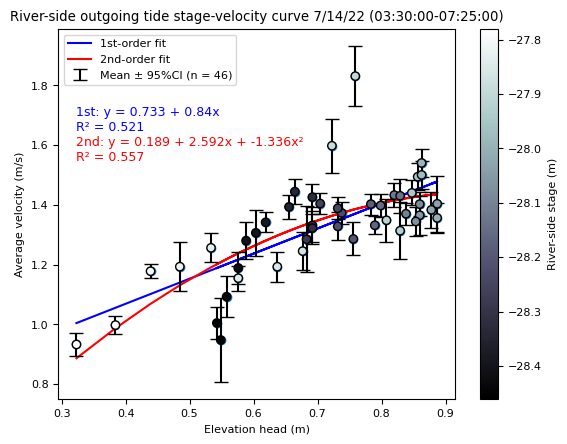

In [46]:
river_outputs_filtered = dropmissing(river_outputs)
river_outputs_filtered = filter(row -> row.Z > 0, river_outputs_filtered)
river_SEMs = [NaNStatistics.nanstd(v) / sqrt(count(!isnan, v)) for v in river_outputs_filtered.velocities]


import Polynomials

plt.figure()
plt.scatter(river_outputs_filtered.Z, 
    Statistics.mean.(river_outputs_filtered.velocities))
plt.xlabel("Elevation head (m)")
plt.ylabel("Average velocity (m/s)")
plt.title("River-side outgoing tide stage-velocity curve 7/14/22 ($(Dates.Time(river_outputs_filtered.times[1]))-$(Dates.Time(river_outputs_filtered.times[end])))")

p_x = river_outputs_filtered.Z
p_y = Statistics.mean.(river_outputs_filtered.velocities)
# First-order polynomial fit (linear)
p1 = Polynomials.fit(p_x, p_y, 1)
y_fit1 = p1.(p_x)
ss_res1 = sum((p_y .- y_fit1).^2)
ss_tot = sum((p_y .- mean(p_y)).^2)
r2_1 = 1 - ss_res1 / ss_tot

# Second-order polynomial fit (quadratic)
p2 = Polynomials.fit(p_x, p_y, 2)
y_fit2 = p2.(p_x)
ss_res2 = sum((p_y .- y_fit2).^2)
r2_2 = 1 - ss_res2 / ss_tot

# Coefficients
c1 = round.(Polynomials.coeffs(p1); digits=3)
c2 = round.(Polynomials.coeffs(p2); digits=3)

# Equations as strings
eq1_str = "1st: y = $(c1[1]) + $(c1[2])x\nR² = $(round(r2_1, digits=3))"
eq2_str = "2nd: y = $(c2[1]) + $(c2[2])x + $(c2[3])x²\nR² = $(round(r2_2, digits=3))"

# Annotate in upper left
annot_x = minimum(p_x)
annot_y = maximum(p_y)

plt.annotate(eq1_str, xy=(annot_x, annot_y-0.1), xycoords="data", fontsize=9, color="blue", verticalalignment="top")
plt.annotate(eq2_str, xy=(annot_x, annot_y - 0.2), xycoords="data", fontsize=9, color="red", verticalalignment="top")

n_points = length(river_outputs_filtered.velocities)

# Plot fits
plt.plot(p_x, y_fit1, label="1st-order fit", color="blue", zorder = 1)
plt.plot(p_x, y_fit2, label="2nd-order fit", color="red", zorder = 1)
plt.errorbar(river_outputs_filtered.Z, NaNStatistics.nanmean.(river_outputs_filtered.velocities), 
    yerr=river_SEMs, fmt="none", capsize=5, label="Mean ± 95%CI (n = $n_points)", color="black", zorder = 2)
plt.scatter(river_outputs_filtered.Z, NaNStatistics.nanmean.(river_outputs_filtered.velocities), 
    c = river_outputs_filtered.WSE_gage, cmap = "bone", zorder = 3, edgecolors = "black")

# Labels and legend
plt.legend(loc="upper left")
plt.colorbar(label = "River-side stage (m)")
plt.gcf()


In [32]:
plt.colormaps()

UndefVarError: UndefVarError: `colormaps` not defined

In [171]:
# Get vector of all images
image_dir = raw"/Volumes/ETH_4TB/CNRD_IR"

ats_files = filter(f -> endswith(f, ".ats"), readdir(image_dir; join=true))
ATS_file_info = DataFrame(first_timestamp = Dates.DateTime[], framerate = Float64[])
# push!(ATS_file_info.filename, ats_files)

for file in ats_files
    ats_images = LoadATSImageSequence(file, 1:3, ats_year)
    first_frame_ts = IRQIV.ats_ts(ats_images)[1]
    est_framerate = ats_images.Metadata.Estimatedfps
    push!(ATS_file_info.first_timestamp, first_frame_ts)
    push!(ATS_file_info.framerate, est_framerate)
end

ATS_file_info = hcat(ats_files, ATS_file_info)
rename!(ATS_file_info, :x1 => :ATS_filepath)

# Can't calculate fps warnings - adding more indices does not help, 12 files have NaN framerate
sum(isnan.(ATS_file_info.framerate))

ATS_file_info.first_timestamp .+= Dates.Hour(1) #What is going on.........



373-element Vector{DateTime}:
 2022-07-11T14:45:25.086
 2022-07-11T14:54:01.786
 2022-07-11T15:05:43.886
 2022-07-11T15:08:21.686
 2022-07-13T08:45:24.048
 2022-07-13T08:56:37.298
 2022-07-13T09:07:50.797
 2022-07-13T09:19:03.963
 2022-07-13T09:30:17.296
 2022-07-13T09:41:30.296
 ⋮
 2022-07-15T08:47:59.900
 2022-07-15T08:53:52.066
 2022-07-15T08:59:44.483
 2022-07-15T09:05:34.899
 2022-07-15T09:11:26.732
 2022-07-15T09:17:20.399
 2022-07-15T09:23:12.815
 2022-07-15T09:29:05.315
 2022-07-15T09:34:59.231

In [172]:
# Temporary - find USGS tide gauge data overlap

USGS_tidegauge = CSV.read(joinpath(CACO_dir, "2022/Analysis/Modeling/WL_model_inputs", "HRE_CNRD_USGS_011058798.csv"), DataFrame, header = 28)[2:end, :]

USGS_datetime = Dates.DateTime.(USGS_tidegauge."datetime", "m/d/y H:M")

test_comp_times = [Dates.DateTime("2022-07-14T03:30:00"),
    Dates.DateTime("2022-07-14T03:45:00"),
    Dates.DateTime("2022-07-14T04:15:00"),
    Dates.DateTime("2022-07-14T04:45:00"),
    Dates.DateTime("2022-07-14T05:30:00"),
    Dates.DateTime("2022-07-14T06:30:00")]

test_ind = 2

test_ATS_inds = [searchsortedlast(ATS_file_info.first_timestamp, t) for t in test_comp_times]
ATS_file_info[test_ATS_inds, :]

Row,ATS_filepath,first_timestamp,framerate
,String,DateTime,Float64
1,/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003352.ats,2022-07-14T03:29:40.481,8.96861
2,/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003354.ats,2022-07-14T03:43:12.925,9.00901
3,/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003358.ats,2022-07-14T04:10:18.146,8.96861
4,/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003363.ats,2022-07-14T04:44:11.701,9.00901
5,/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003369.ats,2022-07-14T05:24:33.477,9.00901
6,/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003378.ats,2022-07-14T06:24:06.030,9.00901


In [173]:
# Initialize MQD vector field

filenum = 3370#3350

# Subwindow dimensions remain constant
const M=32 # subwindow dims - horiz, N = vert.
const N=32
# Search radius - variance STIV lines steeper slopes approx 35pix/frame
const rhoI = 38 # how far away to search (+/-) - i=short side, j= long side
const rhoJ = 38 # Set these to visual estimates - plot one pair
MQD_parameters = (M=M, N=N, rhoI=rhoI, rhoJ=rhoJ)

# Set ATS parameters
Img_dims = [784, 1344] # Image dims: 784 x 1344
DtFrames = 1                    # Δt, frames (ATS 3116 is at 10Hz)
data_output_rate_frames = 1    # difference between I1 sequence, frames - time sep of output
nImagePairs = 101 # can set to inf - all frames in file
Nfiles = 40 # Set number of files to average over

# Load IR images:
I1inds = range(1, step=data_output_rate_frames, length=nImagePairs)
I2inds = I1inds .+ DtFrames

# Crop AOI to area just outside sluicegate
right_crop = 900
# Offset distance (horizontal left shift)
offset_distance = 150  # Pixels

subwincorners = CartesianIndices(( (N+rhoI):N:(Img_dims[1]-(N+rhoI+1)),
                                    (M+rhoJ):M:right_crop))

# FLIR_filename = joinpath("/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-00" * string.(filenum) * ".ats")
FLIR_filename = ATS_file_info.ATS_filepath[test_ATS_inds[test_ind]]
@assert isfile(FLIR_filename)
I1images = LoadATSImageSequence(FLIR_filename, I1inds, ats_year)
I2images = LoadATSImageSequence(FLIR_filename, I2inds, ats_year)
ATSframerate = I1images.Metadata.Estimatedfps

# Run MQD

# Remove image pairs when at least one image took place during NUC (calibration)
# mode:
if any(isnuc(I1images.Headers)) || any(isnuc(I2images.Headers))
    nuc_frames = isnuc(I1images.Headers) .| isnuc(I2images.Headers)
    I1inds = I1inds[.!( isnuc(I1images.Headers) .| isnuc(I2images.Headers) )]
    I2inds = I2inds[.!( isnuc(I1images.Headers) .| isnuc(I2images.Headers) )]
    I1images = LoadATSImageSequence(FLIR_filename, I1inds, ats_year)
    I2images = LoadATSImageSequence(FLIR_filename, I2inds, ats_year)
end

# Initialize MQD calculation:
MQD_variables = initialize_MQD(I1images,
                            I2images,
                            subwincorners,
                            N, M,
                            rhoI, rhoJ)                              

# Perform the MQD analysis:
subpix_shifts_i, subpix_shifts_j, performance_message = perform_MQD(
    I1images, I2images, subwincorners, MQD_variables)

mean_shifts_i = dropdims(NaNStatistics.nanmean(subpix_shifts_i, dims = 3), dims = 3)
mean_shifts_j = dropdims(NaNStatistics.nanmean(subpix_shifts_j, dims = 3), dims = 3)

# Plotting in pixel space (generate indices for vector locations) - issue w/ CSV package in multithread mode
x_vector = [index[2] for index in subwincorners]
y_vector = [index[1] for index in subwincorners]


"/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003354.ats"

In [7]:
# plt.close("all")
# fig,axs = plt.subplots()
# axs.quiver(x_vector, y_vector, mean_shifts_j[:,:], mean_shifts_i[:,:], angles="xy")
# axs.invert_yaxis()
# plt.plot([u_start, u_end], [v_start, v_end], label="Diagonal Line", linewidth=2.5)
# plt.scatter(initial_cols, initial_rows)
# plt.gcf()

In [8]:
# # Visualize frames - SKIP
# # Create a plot window and display the initial image

# fig, ax = plt.subplots()
# im = ax.imshow(I1images[1], cmap="viridis", vmin=10000, vmax=10100)

# # Function to update the image
# function update_image!(new_img)
#     plt.imshow(new_img, cmap="viridis", vmin=10000, vmax=11000)
#     plt.draw()          # Force an update
#     plt.pause(0.001)
# end

# # Close all existing plot windows (optional, if needed)
# plt.close("all")

# # Update the image in a loop
# for i in 1:length(I1images)
#     img = I1images[i]
#     update_image!(img)
#     plt.title("$i")
# end

# plt.show()

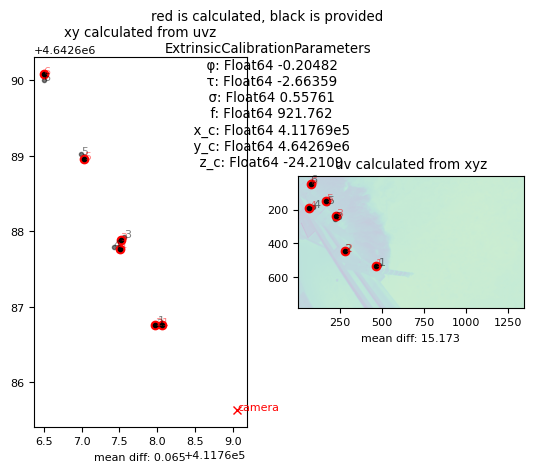

In [175]:
# Camera location calibration - RIVER SIDE:
dlt_us = IRQIV.DLT(χinitial_us, FLIR_SC8303_17mm)
###############################################################################

TrueGCPxyz_us = US_GCP_utm_resurvey # US_GCP_utm_combined

χcalculated_us = ExtrinsicCalibration(
    TrueGCPuv_us,
    TrueGCPxyz_us,
    χinitial_us,
    ι,
    MaxIterations = 50,
    PrintoutStats=true)
# ###############################################################################
@info "Initial guess, χinitial:"
@show dump(χinitial_us)
# 
@info "Calibrated values, χcalculated:"
@show dump(χcalculated_us)
# 
# Describe how much the calibration changed each parameter:
@info "Difference between calibrated value and initial guess:"
for (i,x) in enumerate(fieldnames(typeof(χcalculated_us)))
    if i <= 3
        println("$x diff (degrees) -  $(rad2deg(getfield(χinitial_us, x) - getfield(χcalculated_us, x)))")
    elseif i == 4
        println("$x diff -  $(getfield(χinitial_us, x) - getfield(χcalculated_us, x))")
    else
        println("$x diff (meters) -  $(getfield(χinitial_us, x) - getfield(χcalculated_us, x))")
    end
end

# Extract WSE from thermistor time series using ATS file timestamp
ATS_file_time_us = IRQIV.ats_ts(IRimages_us)
therminds_us = find_nearest_time_indices(ATS_file_time_us, therm.DateTime)
# WSE_mean_ATS_us = χcalculated_us.z_c - therm.WaterDistanceFromCameraM[therminds_us][1
# WSE_mean_ATS = χcalculated_us.z_c - river_gauge_dist_from_cam[2][test_USGS_ind][]
WSE_mean_ATS = χcalculated_us.z_c - river_gauge_dist_from_cam[2][1][]
RectParams_us = IRQIV.ImageRectification.calculate_image_rectification(Camera.pixel_resolution, ι, χcalculated_us, WSE_mean_ATS, interpolated_grid_spacing=0.1)
rectified_image_us = RectParams_us(IRimages_us)
dlt_calculated = IRQIV.DLT(χcalculated_us, FLIR_SC8303_17mm)

plt.close("all")
plt.rc("font", size=8)
GraphicallyExploreInitialCalibrationGuess(TrueGCPuv_us, TrueGCPxyz_us, χcalculated_us, ι, IRimages_us[1])
plt.gcf()

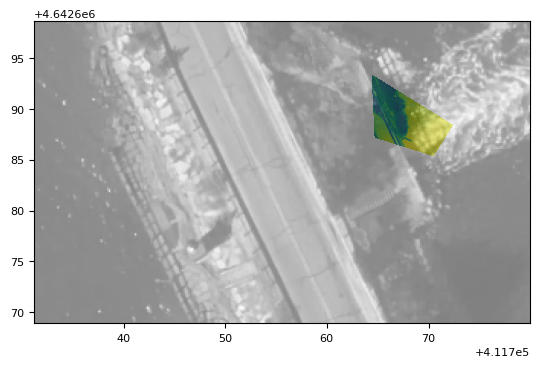

In [ ]:
# Test reprojection against basemap imagery

import ArchGDAL
basemap_path = ArchGDAL.read(raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/CACO/2022/Analysis/ESRI_basemap/ESRI_basemap.tif")
basemap_band = ArchGDAL.getband(basemap_path, 1)
basemap = ArchGDAL.read(basemap_band)
# basemap = reverse(reverse(basemap, dims=1), dims=2)
basemap = permutedims(basemap, (2, 1))
# basemap = reverse(reverse(basemap, dims=2))

# Get the geotransform (affine transformation to map pixel coordinates to world coordinates)
geotransform = ArchGDAL.getgeotransform(basemap_path)

# Get the dimensions of the image
width = ArchGDAL.width(basemap_path)
height = ArchGDAL.height(basemap_path)

# Extract the geotransform values
x_min = geotransform[1]
y_max = geotransform[4]
x_res = geotransform[2]  # Pixel width
y_res = geotransform[6]  # Pixel height (negative)

# Calculate the extents
x_max = x_min + size(basemap, 2) * x_res
y_min = y_max + size(basemap, 1) * y_res

# Extent for imshow
basemap_extent = (x_min, x_max, y_min, y_max)

# Get the projection (coordinate system)
projection = ArchGDAL.getproj(basemap_path)

println("Geotransform: ", geotransform)
println("Projection: ", projection)

plt.close("all")
plt.imshow(rectified_image_us, extent=RectParams_us.extent)
plt.imshow(basemap, extent=basemap_extent, alpha = 0.5, cmap = "gray")
plt.gcf()

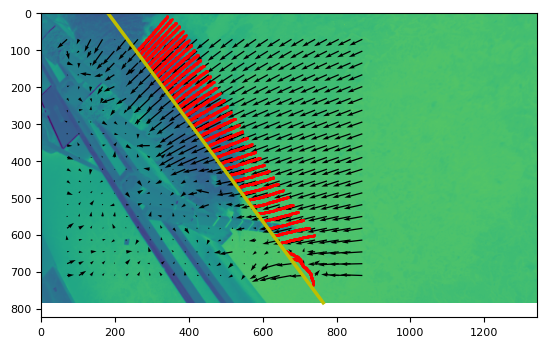

In [231]:
import LinearAlgebra
# Define initial conditions from which to start numerical integration of vector field - want 40 equidistant points

# Interpolate vector field for numerical integration
i = Float64[y_vector[:,1]...]
j = Float64[x_vector[1,:]...]
X, Y = meshgrid(j, i)
# Create linear interpolants for the vector field - make i & j shifts negative to integrate upstream
u_interp = extrapolate(interpolate((i, j), -mean_shifts_i, Gridded(Linear())), Line())
v_interp = extrapolate(interpolate((i, j), -mean_shifts_j, Gridded(Linear())), Line())

# Set up shadow as integration start line
shadow_start_uv = [182,1] # [u,v]
shadow_end_uv = [764,784] # [u,v]
u_start, v_start = shadow_start_uv
u_end, v_end = shadow_end_uv
# Interpolate boundary condition where streamlines end - don't change variable name, feeds into terminate_at_bounds()
shadow_interp = LinearInterpolation(Float64[v_start, v_end], Float64[u_start, u_end]; extrapolation_bc=Line())
# Get pixels along shadow line
shadow_pixels_uv = bresenham_line(v_start, u_start, shadow_end_uv[2], shadow_end_uv[1])
# Get physical locations of shadow line start and end points
shadow_start_xy = IRQIV.uvz2xy(u_start, v_start, WSE_mean_ATS, dlt_calculated)
shadow_end_xy = IRQIV.uvz2xy(shadow_end_uv[1], shadow_end_uv[2], WSE_mean_ATS, dlt_calculated)
# Calculate the total distance of the line (Euclidean distance)
delta_x = shadow_end_xy[1] - shadow_start_xy[1]
delta_y = shadow_end_xy[2] - shadow_start_xy[2]
line_length = sqrt(delta_x^2 + delta_y^2)
# Get physical locations of all pixels along line
shadow_pixels_xy = fill((0.0, 0.0), length(shadow_pixels_uv))
for (coord_ind, coord) in enumerate(shadow_pixels_uv)
    v_ind, u_ind = coord
    x_coord, y_coord = IRQIV.uvz2xy(u_ind, v_ind, WSE_mean_ATS, dlt_calculated)
    shadow_pixels_xy[coord_ind] = (x_coord, y_coord)
end

# Number of equidistant points you want
n = 40
max_n = 200

# Create empty vector of sets, one for each streamline
StreamlinePixelsSingle = []

while n < max_n
    plt.close("all")

    scratch_streamlines = []

    # Generate 40 equidistant distances along the line (in terms of total length)
    distances = LinRange(0, line_length, n)

    # Now calculate the corresponding (x, y) positions for each distance
    # Parametrize the line using the formula: (x, y) = (x_start + t * delta_x, y_start + t * delta_y)
    equidistant_points = [shadow_start_xy + (distance / line_length) * StaticArrays.SVector(delta_x, delta_y) for distance in distances]

    # Now, for each equidistant point, find the closest pixel in shadow_pixels_xy
    start_point_indices = []
    for eq_point in equidistant_points
        # Find the pixel in shadow_pixels_xy that has the minimum distance to eq_point
        distances_to_pixels = [LinearAlgebra.norm(eq_point .- pixel) for pixel in shadow_pixels_xy]
        min_index = argmin(distances_to_pixels)  # Find the index of the minimum distance
        push!(start_point_indices, min_index)
    end

    initial_conditions = shadow_pixels_uv[start_point_indices]
    all_streamline_coords = [] # Initialize default array
    # Compute streamlines for all starting points
    for sp in initial_conditions
        coords = compute_streamline(sp, all_streamline_coords)
    end

    # Iterate through each streamline in `all_streamline_coords`
    for coords in all_streamline_coords
        # Define a set to store unique pixels for the current streamline
        streamline_pixels = []  # Use an ordered vector instead of a set

        for k in 1:length(coords)-1
            y0, x0 = coords[k]
            y1, x1 = coords[k+1]

            # Calculate Bresenham pixels for the current segment
            bresenham_pixels = bresenham_line(round(Int, y0), round(Int, x0), round(Int, y1), round(Int, x1))
            
            # Filter pixels that are beyond the diagonal line
            filtered_pixels = filter(p -> right_of_diagonal(p[2], p[1], u_start, v_start, u_end, v_end), bresenham_pixels)

            # Add pixels to the current streamline set
            append!(streamline_pixels, filtered_pixels)    
        end
        
        # Add the unique set of pixels for this streamline to the overall list
        push!(scratch_streamlines, streamline_pixels)
    end

    # collect() puts vector of indices in order
    scratch_streamlines = [collect(streamline) for streamline in scratch_streamlines]

    # reverse() first nImagePairs to account for reverse integration of vector field
    scratch_streamlines = [
        reverse(length(streamline) > nImagePairs ? streamline[1:nImagePairs] : streamline)
        for streamline in scratch_streamlines
    ]
    
    # Filter scratch_streamlines for valid image indices and length = nImagePairs
    scratch_streamlines = [
        streamline for streamline in scratch_streamlines
        if length(streamline) >= nImagePairs && 
        all(p -> p[1] > 0 && p[2] > 0, streamline) &&
        all(p -> p[1] <= Img_dims[1] && p[2] <= Img_dims[2], streamline)
    ]

    # Check if we have 40 valid streamlines
    if length(scratch_streamlines) == 40
        StreamlinePixelsSingle = scratch_streamlines
        break
    end

    n += 1  # Increase n and try again
end

fig, ax = plt.subplots()
ax.quiver(X, Y, mean_shifts_j, mean_shifts_i, angles="xy") # Why the ' on U and V?
for streamline_pixels in StreamlinePixelsSingle
    for (y, x) in streamline_pixels
        ax.plot(x, y, "ro", markersize=1, label="Streamline Pixels")
    end
end
plt.imshow(IRimages_us[1])
plt.plot([u_start, u_end], [v_start, v_end], label="Diagonal Line", linewidth=2.5, "y")
# ax.invert_yaxis()

length(StreamlinePixelsSingle)
plt.gcf()

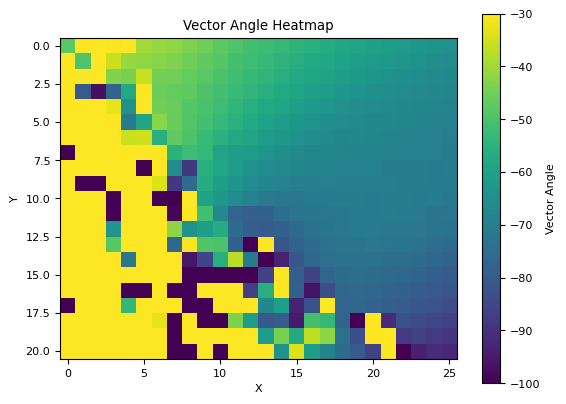

In [239]:
using Interpolations

u_interp = interpolate((i, j), mean_shifts_i, Gridded(Linear()))
v_interp = interpolate((i, j), mean_shifts_j, Gridded(Linear()))

magnitude_interp = sqrt.(u_interp.^2 .+ v_interp.^2)

magnitude = sqrt.(mean_shifts_j.^2 .+ mean_shifts_i.^2)
angle = rad2deg.(atan.(mean_shifts_j, mean_shifts_i))
interp_magnitude = interpolate((i, j), magnitude, Gridded(Linear()))
interp_magnitude_array = [interp_magnitude[ii, jj] for ii in i, jj in j]
interp_angle = interpolate((i, j), angle, Gridded(Linear()))
interp_angle_array = [interp_angle[ii, jj] for ii in i, jj in j]

# Plot as heatmap
plt.figure()
plt.imshow(interp_angle_array, cmap="viridis", origin="upper")  # Use any colormap you like
plt.clim(-100,-30)
plt.colorbar(label="Vector Angle")
plt.title("Vector Angle Heatmap")
plt.xlabel("X")
plt.ylabel("Y")
plt.gcf()

In [192]:
mean_shifts_i

21×26 Matrix{Float64}:
 13.4538     7.8016    18.7925     …  10.1338    9.62403    9.3091
 12.8784     3.19392   10.5195         9.869     9.30828    9.00632
  3.485      7.86288    4.90615        9.43434   9.18956    8.86341
  1.25002    0.492839  -2.04348        9.26365   8.95609    8.70162
 -1.24566    4.56673    7.63089        9.2145    9.01074    8.78686
  4.30495    5.55871    5.64025    …   9.12064   8.98837    8.746
  3.63128   -0.916685  -6.41856        9.11111   8.99958    8.58324
 -1.91937   -1.60151   -0.195812       9.15282   8.86974    8.39353
 -1.4012    -0.685012   1.76967        8.66072   8.48477    8.63079
  0.464277  -5.24427   -2.18255        8.83517   8.60863    8.66539
  ⋮                                ⋱                        ⋮
  4.06271    1.91056    2.75642        8.45813   8.19501    7.88871
  3.15019   -3.05072   -2.9691         7.98867   7.43032    7.17828
 -1.00419   -4.34429   -6.73127        7.29425   6.70884    6.26746
  0.528706  -4.50752   -7.32394   

In [17]:
# Automatic STIV detection routine: from Fujita et al. 2019 https://doi.org/10.1007/s10652-018-9651-3
import HDF5
import FFTW
plt.pygui(true) # sets plots to popup instead of inline

# Polygon mask functions from https://github.com/JuliaImages/ImageDraw.jl/issues/56

# This function returns whether or not a point falls within a polygon
function point_in_polygon(poly_xs::Vector{T}, poly_ys::Vector{T}, x::T, y::T) where T<: Real
    n_verts = length(poly_xs)
    j = n_verts
    c = false
    for i in 1:n_verts
        if (((poly_ys[i] <= y) && (y < poly_ys[j])) || ((poly_ys[j] <= y) && (y < poly_ys[i]))) && 
            (x < (poly_xs[j] - poly_xs[i]) * (y - poly_ys[i]) / (poly_ys[j] - poly_ys[i]) + poly_xs[i])
            c = !c
        end
        j = i
    end
    return c
end

# This function uses the above function to populate a boolean mask within the given polygon
function draw_polygon!(mask::Matrix{Bool}, poly_xs::Vector{Int}, poly_ys::Vector{Int})
    min_x, max_x = max(minimum(poly_xs), 1), min(maximum(poly_xs), size(mask, 2))
    min_y, max_y = max(minimum(poly_ys), 1), min(maximum(poly_ys), size(mask, 1))
    for y in min_y:max_y
        for x in min_x:max_x
            if point_in_polygon(poly_xs, poly_ys, x, y)
                mask[y, x] = true
            end
        end
    end
end

# This function uses the above two function to create the circular mask for the STIV polar coordinate transform
function polygons_to_mask(polygons::Array{Matrix{T}, 1} where T <: Real, max_x::Int, max_y::Int)::Matrix{Bool}
    poly_mask = zeros(Bool, max_y, max_x)  # Initialize a Bool matrix with all values set to false
    for p in polygons
        draw_polygon!(poly_mask, round.(Int, p[:, 1]), round.(Int, p[:, 2]))
    end
    return poly_mask
end


polygons_to_mask (generic function with 1 method)

In [ ]:
import Images, ImageEdgeDetection
using ImageEdgeDetection: Percentile

filter_rad = 25 # Filter radius for canny algorithm
STIV_line_threshold=50 # How long of lines will have their slopes calculated
alg = ImageEdgeDetection.Canny(spatial_scale=filter_rad, high=Percentile(80), low=Percentile(20))

plt.close("all")

# Set pixel intensity limits for figure
vmin_val = 10400
vmax_val = 10800

# Loop through all intersecting streamlines and calculate STIV slope

STIV_time_vec = Dates.Time.(IRQIV.ats_ts(I1images))

ATS_file_time = IRQIV.ats_ts(I1images)
# therminds = find_nearest_time_indices(ATS_file_time, therm.DateTime)
# WSE_mean_ATS = χcalculated_us.z_c - therm.WaterDistanceFromCameraM[therminds[1]]

STIV_vels = zeros(length(StreamlinePixelsSingle))
pixel_sizes = zeros(length(StreamlinePixelsSingle))

# Initialize STIV elements
slope_vec = []
center = Int(ceil(nImagePairs/2))
radius = center-1
# Define angles and compute coordinates for the circle mask
θ_c = range(1, stop = 360, length = 360)
xc = radius * cosd.(θ_c) .+ center
yc = radius * sind.(θ_c) .+ center
# Create a circular mask
circ_mask = polygons_to_mask([hcat(xc, yc)], center+radius, center+radius)
circ_nan = ones(Float64, size(circ_mask))
circ_nan[.!circ_mask] .= NaN
# Initialize arrays for polar transform
θ = zeros(Float64, nImagePairs, nImagePairs)
ρ = zeros(Float64, nImagePairs, nImagePairs)
Tx = zeros(Float64, nImagePairs, nImagePairs)
Ty = zeros(Float64, nImagePairs, nImagePairs)
M_STIV = 15  # "coefficient of intensification" from Fujita
# Calculate theta and ρ for each pixel within the mask - polar transform
for i in 1:nImagePairs
    for j in 1:nImagePairs
        if circ_mask[i, j]
            Tx[i,j] = center - j
            Ty[i,j] = center - i
            θ[i,j] = atand(Ty[i,j] / Tx[i, j]) # -90 to 90
            ρ[i,j] = M_STIV * log(sqrt(Tx[i,j]^2 + Ty[i,j]^2)) 
        end
    end
end
# Initialize polar coordinates
AngleIncrement = 1
AngleVec = [0:1*AngleIncrement:179]
inds_vec = zeros(Int, length(AngleVec[1]))
μ = zeros(Float64, length(AngleVec[1]))

# Loop through each streamline
for (stream_ind, streamline_uv) in enumerate(StreamlinePixelsSingle)
    # Locate the intersection index for trimming
    streamline_uv = remove_duplicate_coords(streamline_uv)

    # Calculate physical locations of STIV lines
    xy_coords = fill((0.0, 0.0), length(streamline_uv))
    for (coord_ind, coord) in enumerate(streamline_uv)
        v_ind, u_ind = coord
        x_coord, y_coord = IRQIV.uvz2xy(u_ind, v_ind, WSE_mean_ATS, dlt_calculated)
        xy_coords[coord_ind] = (x_coord, y_coord)
    end

    # Create empty vector of vectors (each vector is 1 STIV column)
    STIV_vec = Vector{Vector{Float64}}()
    dist_vec = nothing

    # Extract pixel values for the trimmed streamline across the image time series
    for img = 1:size(I1images, 3)
        pixel_intensities = zeros(length(streamline_uv))
        for coord = 1:length(streamline_uv)
            i, j = streamline_uv[coord]
            pixel_intensities[coord] = I1images[i, j, img] # (i, j) for row, col order
        end
        uniform_distances, interpolated_intensities = interpolate_preserving_points(xy_coords, pixel_intensities)
        push!(STIV_vec, interpolated_intensities)

        if img == 1
            dist_vec = collect(uniform_distances)
            pixel_sizes[stream_ind] = dist_vec[2]

            # Skip this streamline if there aren't enough distance samples
            if length(interpolated_intensities) < nImagePairs
                @warn "Skipping streamline $stream_ind: only $(length(interpolated_intensities)) pixels < $nImagePairs"
                continue
            end
        end
    end

    # Unpack the vector of vectors to a 2D array
    STIV_vec = hcat(STIV_vec...)

    # Assemble STIV space-time diagram
    for row = 1:size(STIV_vec, 1)
        STIV_vec[row, :] = STIV_vec[row, :] .- Statistics.mean(STIV_vec[row, :])
    end

    # Fujita STIV
    y = STIV_vec[end-(nImagePairs-1):end, :]
    # Compute the 2D Fourier transform and the power spectrum of the STIV window (Rxy)
    Rxy = FFTW.ifft(abs.(FFTW.fft(y)).^2)
    Rxy = FFTW.fftshift(abs.(Rxy)) # Shifts zero-frequency component to center of spectrum
    # Apply the circular mask to Rxy
    Rxy_pol_norm = Rxy .* circ_nan ./ Rxy[center, center]
    ρ_Rxy = ρ .* circ_nan
    θ_Rxy = θ .* circ_nan
    # Log-transformation for distance from STIV window center
    ρ_max = M*log(minimum([maximum(filter(!isnan,Tx)),maximum(filter(!isnan,Ty))]))
    # Loop through vector of angles
    for i in 1:length(AngleVec[1])
        a = i-90 # Convert index back to angle of theta
        inds = findall(θ -> round(θ) == a, θ[:]) # Find all pixels within each degree increment
        inds_vec[i] = length(inds)
        Rxy_int = sum(Rxy_pol_norm[inds])/inds_vec[i] # Square summed intensity within each degree to amplify signal (optional), normalize by number of pixels in degree
        μ[i] = (1/ρ_max)*Rxy_int # Calculate normalized integral value for each degree
    end

    # Exclude invalid measurements 
    exclude_inds = Set([0, 90, 180])  # Indices to exclude
    valid_inds = [i for i in eachindex(μ) if !isnan(μ[i]) && !(i in exclude_inds)]
    max_local_idx = argmax(@view μ[valid_inds])
    φ = valid_inds[max_local_idx] - 90 # Convert integral back to angles centered at 0
    push!(slope_vec, φ) # Populate vector of measurements with result
    Sx = pixel_sizes[stream_ind]
    St = 1/ATSframerate
    STIV_vels[stream_ind] = Sx/St*tand(φ)

    # Plot the results
    u_coords = [coord[2] for coord in streamline_uv]  # x = col index
    v_coords = [coord[1] for coord in streamline_uv]  # y = row index
     
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    # Plot the original image with the streamline
    im1 = ax1.imshow(I1images[:,:,1], cmap="viridis", vmin = vmin_val, vmax = vmax_val)  # Show the first frame or another reference image
    ax1.plot(u_coords, v_coords, "r", linewidth=2.5)  # Overlay the streamline in red
    ax1.set_title("Streamline")
    ax1.set_xlabel("U coordinate (pix)")
    ax1.set_ylabel("V coordinate (pix)")
    
    # Plot the STIV image
    im2 = ax2.imshow(y, cmap="viridis")  # Display STIV vector
    ax2.set_title("STIV Image, ypix = $(size(STIV_vec))")
    ax2.set_xticks(collect(1:49:nImagePairs))
    ax2.set_xticklabels(string.(STIV_time_vec[1:49:nImagePairs]))
    ax2.set_yticks(collect(1:20:length(dist_vec)))
    ax2.set_yticklabels(round.(dist_vec[1:20:length(dist_vec)], digits = 3))
    ax2.set_xlabel("Time on 7/14/22 (HH:mm:ss.ms)")
    ax2.set_ylabel("Distance (m)")
    xEdge = center + radius * cosd(φ)
    yEdge = center + radius * sind(φ)
    ax2.plot([center, xEdge], [center, yEdge-1], color="red", lw=2)
    
    # Plot the labeled components (slope map)
    im3 = ax3.plot(AngleVec[1].-90, μ)
    ax3.set_title("Fujita method μ; φ = $φ")
    ax3.set_xlabel("Angle (degrees)")
    ax3.set_ylabel("Normalized autocorrelation")

    fig.suptitle("Velocity = $(round(STIV_vels[stream_ind], sigdigits = 3)) m/s; pixel_size = $(round(pixel_sizes[stream_ind]*100, sigdigits = 3)) cm")
end

# plt.show()

sys:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.


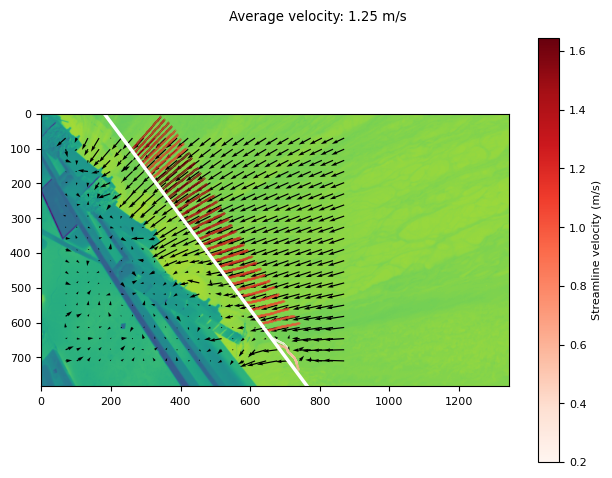

In [19]:
using PyCall
normalize = pyimport("matplotlib.colors").Normalize

plt.close("all")

min_vel = minimum(STIV_vels)
max_vel = maximum(STIV_vels)
cmap = plt.get_cmap("Reds")  # Choose a colormap (e.g., "viridis")

fig, ax = plt.subplots()
plt.imshow(I1images[1])#, vmin = vmin_val, vmax = vmax_val)#, extent=(left_crop, Img_dims[2], Img_dims[1], 0),cmap="viridis")
ax.quiver(X, Y, mean_shifts_j, mean_shifts_i, angles="xy")

for (i, streamline_pixels) in enumerate(StreamlinePixelsSingle)
    velocity = STIV_vels[i]
    streamline_color = cmap((velocity - min_vel) / (max_vel - min_vel))  # Map to 0–1 range for the colormap
    # dump((velocity - min_vel) / (max_vel - min_vel))
    for (y, x) in streamline_pixels
        ax.plot(x, y, marker="o", color=streamline_color, markersize=.2, label="Streamline Pixels")
    end
end

# Set labels and title
plt.plot([u_start, u_end], [v_start, v_end-1], label="Diagonal Line", linewidth=2.5, "w")

# Add a colorbar
norm = normalize(vmin=min_vel, vmax=max_vel)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Streamline velocity (m/s)")
fig.suptitle("Average velocity: $(round(mean(STIV_vels), digits = 2)) m/s")
plt.tight_layout()

plt.gcf()

In [20]:
# Compare with normal component of MQD vectors

# Calculate physical dimensions of vector field
displacement_x, displacement_y, centroid_x_origin, centroid_y_origin = pixel2physical_displacements(subwincorners, 
                                                                                                        mean_shifts_i, 
                                                                                                        mean_shifts_j, 
                                                                                                        M, N, 
                                                                                                        WSE_mean_ATS,
                                                                                                        dlt_calculated)


us_transect_start_u = u_start + M + rhoJ # subtract here bc shadow on rhs of image - us it was on lhs
us_transect_start_v = v_start + N + rhoI # First point in vertical pixels - edge of image + search radius + subwindow size
# [ds_transect_start_u, ds_transect_start_v]
us_transect_end_v = v_end - N - rhoI

# Find angle of shadow theta
us_shadow_theta = atan(1/shadow_slope)

# Select subwindows for quantification
subwin_inds_vec = hcat(vec(getindex.(subwincorners,2)), vec(getindex.(subwincorners,1))) # [u, v]

# Filter by row in v coordinate :
subwin_v_coords = getindex.(subwincorners,1)[:,1] # vector of subwindow v pixel coordinates (vertical)
subwin_u_coords = getindex.(subwincorners,2)[1,:] # vector of subwindow u pixel coordinates (horizontal)

subwin_diag_u_inds = zeros(1:length(subwin_v_coords))
subwin_diag_u_inds[1] = findfirst(subwin_u_coords .>= us_transect_start_u) # index in horiz of last subwindow located <= from transect start at top of image

# find u coordinate for each subwindow along diagonal to have one subwindow in each row of v
subwin_diag_u = subwin_u_coords[Int(subwin_diag_u_inds[1])] # find starting u coordinate

for i = 2:length(subwin_v_coords) # for every row in v 
    subwin_diag_u = subwin_diag_u + N/shadow_slope # from previous u coordinate, go 
    subwin_diag_u_inds[i] = findfirst(subwin_u_coords .>= subwin_diag_u)
end

subwin_diag_u_inds
subwin_diag_v_inds = vec(1:length(subwin_v_coords))

# Create mask to isolate indices of subwindows of interest
subwin_mask = zeros(size(subwincorners))
replace!(subwin_mask, 0=>NaN)

for u = 1:size(subwin_mask,2)
    for v = 1:size(subwin_mask,1)
        u_ind = subwin_diag_u_inds[v] # 15
        v_ind = subwin_diag_v_inds[v]
        if u == u_ind && v == v_ind # find subwindow indices in 2d arrays
            subwin_mask[v,u] = 1
        else
        end
    end
end

displacement_x_masked = displacement_x .* subwin_mask
displacement_y_masked = displacement_y .* subwin_mask
inst_disp = hypot.(displacement_x_masked, displacement_y_masked)
inst_disp_alpha = atan.(displacement_y_masked./displacement_x_masked)
inst_disp_field_normal = inst_disp .* cos.(inst_disp_alpha .- us_shadow_theta)

dt = 1/I1images.Metadata.Estimatedfps
normal_vel_profile = NaNStatistics.nanmean(inst_disp_field_normal, dims = (2)) ./ dt

mean_shifts_i_masked = mean_shifts_i .* subwin_mask
mean_shifts_j_masked = mean_shifts_j .* subwin_mask
fig, ax = plt.subplots()
plt.imshow(I1images[1], vmin = vmin_val, vmax = vmax_val)#, extent=(left_crop, Img_dims[2], Img_dims[1], 0),cmap="viridis")
ax.quiver(X, Y, mean_shifts_j_masked, mean_shifts_i_masked, angles="xy")
plt.plot([u_start, u_end], [v_start, v_end-1], label="Diagonal Line", linewidth=2.5, "w")
fig.suptitle("Average velocity: $(round(mean(normal_vel_profile), digits = 2)) m/s")
plt.gcf()

UndefVarError: UndefVarError: `shadow_slope` not defined

In [21]:
# test_rating_curve = DataFrame(datetime = Dates.DateTime[],
#     mean_vel = Float64[],
#     Z = Float64[],
#     streamline_vels = Vector{Vector{Float64}}[],  # <-- key fix here
#     filename = String[]
# )


In [22]:
push!(test_rating_curve, (datetime = ATS_file_info.first_timestamp[test_ATS_inds[test_ind]],
    mean_vel = mean(STIV_vels),
    Z = only(USGS_deltaH[2][test_USGS_ind]),
    streamline_vels = [STIV_vels],
    filename = FLIR_filename
))
test_rating_curve

UndefVarError: UndefVarError: `test_rating_curve` not defined

In [23]:
plt.figure()
plt.rc("font", size = 12)
plt.scatter(test_rating_curve.Z[1:3], test_rating_curve.mean_vel[1:3])
plt.xlabel("Z (m): hRiver-hBay")
plt.ylabel("Velocity (m/s): averaged for all streamlines")
plt.gcf()

UndefVarError: UndefVarError: `test_rating_curve` not defined

In [24]:
using Dates, DataFrames
using IRQIV

image_dir = raw"/Volumes/ETH_4TB/CNRD_IR"

ats_files = filter(f -> endswith(f, ".ats"), readdir(image_dir; join=true))
# ATS_file_info = DataFrame(first_timestamp = Dates.DateTime[], framerate = Float64[])


373-element Vector{String}:
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003207.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003208.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003209.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003210-__TIME__.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003216-__TIME__.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003217-__TIME__.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003218-__TIME__.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003219-__TIME__.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003220-__TIME__.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003221-__TIME__.ats"
 ⋮
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003577.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003578.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003579.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003580.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003581.ats"
 "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003582.ats"
 "/Volumes/ETH_4TB/CNRD_IR

In [25]:
testfile = ats_files[200]
testfile = FLIR_filename

metatest = IRQIV.FLIRATSFiles.FindATSFileMetadata(testfile, ATSfps = NaN)
dump(metatest) # Metadata summary from ATS file 
lastframe = metatest.EstimatedTotalFrames
metatest_fullrange = collect(1:1:lastframe) 
# ATS_file_info.ATS_filepath[10]
_,all_meta = IRQIV.FLIRATSFiles.LoadMultipleFrames(metatest, metatest_fullrange, ats_year=ats_year, ReadFrame=false)

# Can also read frames
metatest_fullrange = collect(1:1:10)#metatest.EstimatedTotalFrames)
whatisthis,I1headers = IRQIV.FLIRATSFiles.LoadMultipleFrames(metatest, metatest_fullrange, ats_year=ats_year, ReadFrame=true)

IRQIV.FLIRATSFiles.ATSFileMetadata
  Name: String "Rec-DeFreesLab_-003354.ats"
  Path: String "/Volumes/ETH_4TB/CNRD_IR"
  FilenameWithPath: String "/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-003354.ats"
  ATSnumFromName: String "003354"
  IntegrationTime: Float64 0.009000000000000001
  FirstFrameCounter: Int64 140395
  Im1Offset: Int64 3329
  ImHeight: Int64 784
  ImWidth: Int64 1344
  BHPHeaderSize: Int64 2688
  ImSize: Int64 2107392
  EstimatedTotalFrames: Int64 3200
  Estimatedfps: Float64 8.98876404494382
  FirstFrameTimestamp: DateTime
    instant: Dates.UTInstant{Millisecond}
      periods: Millisecond
        value: Int64 63698755392925
  FirstFrameTimestampString: String "2019-07-14 02:43:12"


([0x2697 0x268f … 0x2973 0x297a; 0x2696 0x26a7 … 0x297e 0x297e; … ; 0x25d3 0x25d8 … 0x294b 0x2947; 0x25d6 0x25cd … 0x2952 0x2957;;; 0x2693 0x269b … 0x2977 0x2980; 0x26a0 0x2699 … 0x297a 0x2984; … ; 0x25de 0x25d6 … 0x294b 0x294e; 0x25d3 0x25c8 … 0x2944 0x2948;;; 0x268d 0x2692 … 0x296f 0x296b; 0x26a0 0x269f … 0x297a 0x2963; … ; 0x25d7 0x25db … 0x2953 0x2947; 0x25db 0x25c9 … 0x294b 0x2963;;; 0x269e 0x269a … 0x2969 0x2978; 0x2698 0x2694 … 0x2972 0x2979; … ; 0x25d5 0x25c8 … 0x295b 0x295d; 0x25d2 0x25cb … 0x2959 0x296c;;; 0x2688 0x269a … 0x295e 0x295a; 0x2696 0x269a … 0x2968 0x296a; … ; 0x25d9 0x25d2 … 0x293f 0x2947; 0x25d1 0x25be … 0x294e 0x2947;;; 0x2685 0x2692 … 0x2941 0x2953; 0x269a 0x269f … 0x294a 0x2948; … ; 0x25cb 0x25c6 … 0x2955 0x2955; 0x25d8 0x25c3 … 0x2950 0x2952;;; 0x268b 0x2692 … 0x297a 0x2989; 0x269f 0x2697 … 0x2982 0x2980; … ; 0x25d3 0x25d6 … 0x2959 0x2959; 0x25cf 0x25be … 0x2955 0x2963;;; 0x268f 0x2691 … 0x294a 0x2951; 0x2694 0x2699 … 0x2953 0x2950; … ; 0x25d4 0x25ca … 0x2959

In [26]:
# Correcting camera time in timestamp metadata: ALWAYS SPECIFY ats_year = ats_year

# Get metadata timestamp from ATS header
flirmeta_testtime = IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(all_meta, ats_year = ats_year)[1] # First frame corresponds to file created time
flirmeta_testtime = TimeZones.ZonedDateTime(flirmeta_testtime, TimeZones.tz"America/New_York")
println(flirmeta_testtime)

# Get file created timestamp (corresponding to first frame) from base stat file function

filemeta_testtime = TimeZones.ZonedDateTime(Dates.unix2datetime(stat(testfile).mtime), TimeZones.tz"UTC")
filemeta_testtime = TimeZones.astimezone(filemeta_testtime, TimeZones.tz"America/New_York")
println(filemeta_testtime)

# Calculate difference - appears to change slightly between files, FLIR metadata roughly 66 mins behind file metadata
println("Time difference (minutes): ", (flirmeta_testtime - filemeta_testtime) / Minute(1))

2022-07-14T02:43:12.925-04:00
2022-07-14T03:49:30-04:00
Time difference (minutes): -66.28458333333333


In [41]:

filenum = 3348
FLIR_filename = joinpath("/Volumes/ETH_4TB/CNRD_IR/Rec-DeFreesLab_-00" * string.(filenum) * ".ats")
filemeta_time = TimeZones.ZonedDateTime(Dates.unix2datetime(stat(FLIR_filename).mtime), TimeZones.tz"UTC")
filemeta_time = TimeZones.astimezone(filemeta_testtime, TimeZones.tz"America/New_York")

metatest = IRQIV.FLIRATSFiles.FindATSFileMetadata(FLIR_filename, ATSfps = NaN)
_,all_meta = IRQIV.FLIRATSFiles.LoadMultipleFrames(metatest, metatest_fullrange, ats_year=ats_year, ReadFrame=false)

flirmeta_testtime = IRQIV.FLIRATSFiles.ParseBHPHeaderTimestamp(all_meta, ats_year = ats_year)[1] # First frame corresponds to file created time
flirmeta_testtime = TimeZones.ZonedDateTime(flirmeta_testtime, TimeZones.tz"America/New_York")

println("Time difference (minutes): ", (flirmeta_testtime - filemeta_testtime) / Minute(1))

Time difference (minutes): -68.31976666666667
